# Client Statistics Dashboard

Fetches and visualizes client billing and LLM usage statistics from the Andromeda database.

## Sections
1. **Setup** — packages, DB connection, config
2. **Current Month Summary** — records & revenue per client
3. **Month-over-Month Growth** — records and revenue growth %
4. **Revenue Trend** — line chart per client
5. **Cumulative YTD Revenue** — running total
6. **Daily Volume Heatmap** — document volume by day
7. **Harvest Job Efficiency** — records per job
8. **Pareto / Top Clients** — 80/20 volume analysis
9. **LLM Cost per Client** — token usage & cost in EUR
10. **Model Usage Over Time** — which models, volume and cost
11. **Monthly LLM Cost Trend** — cumulative cost line

## 1. Setup

In [1]:
# Uncomment on first run
# !pip install psycopg2-binary pandas matplotlib seaborn

In [2]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import date

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

In [3]:
# ── SECRETS ──────────────────────────────────────────────────
# Loaded from the .env file in THIS project folder (git-ignored).
# First run:  cp .env.example .env  and fill it in.
# Start Jupyter from this folder so the kernel's working directory matches.
import os
from pathlib import Path

from dotenv import load_dotenv

ENV_PATH = Path.cwd() / '.env'
if not ENV_PATH.is_file():
    raise RuntimeError(
        f'No .env found at {ENV_PATH}. Copy .env.example to .env in this '
        f'project folder and fill it in (and start Jupyter from this folder).'
    )
load_dotenv(ENV_PATH)


def env(name, default=None, required=True):
    """Read a setting from this folder's .env / the environment."""
    val = os.getenv(name, default)
    if required and not val:
        raise RuntimeError(
            f'Missing required setting: {name}. Add it to {ENV_PATH} '
            f'(see .env.example).'
        )
    return val

# ── DB CONFIG ─────────────────────────────────────────────────
DB = dict(
    host     = env('ANDROMEDA_DB_HOST'),
    port     = int(env('ANDROMEDA_DB_PORT', 5432)),
    dbname   = env('ANDROMEDA_DB_NAME'),
    user     = env('ANDROMEDA_DB_USER'),
    password = env('ANDROMEDA_DB_PASSWORD'),
    sslmode  = env('ANDROMEDA_DB_SSLMODE', 'require'),
)

# ── REPORT PERIOD ─────────────────────────────────────────────
# REPORT_YEAR  = date.today().year
# REPORT_MONTH = date.today().month


REPORT_YEAR  = 2026
REPORT_MONTH = 9

# ── STATE FILTER (billing) ─────────────────────────────────────
# 12=DUPLICATE_DETECTED, 18=DATA_UPLOADED, 20=ATTACHMENT_UPLOADED
STATE_FILTER = 'r.state_id IN (12, 18, 19, 20)'       # current
# STATE_FILTER = 'r.state_id >= 11'               # legacy (pre-2025)

# ── ERROR STATES ───────────────────────────────────────────────
# is_final=true AND is_ok=false
ERROR_STATES = (2, 3, 5, 9, 10, 17, 21)

# ── UNBILLED STATES (harvested but not billed) ─────────────────
# state >= 11 AND NOT IN billing states
UNBILLED_STATES = (11, 13, 14, 15, 16, 17, 21)

# ── LLM PRICING (EUR per 1M tokens) ───────────────────────────
PRICE_INPUT        = 2.101   # €/1M input tokens
PRICE_CACHED_INPUT = 0.526   # €/1M cached input tokens
PRICE_OUTPUT       = 8.41    # €/1M output tokens
PRICE_TRAINING     = 26.3    # €/1M training tokens
PRICE_HOSTING_HOUR = 1.5     # €/hour hosting

print(f'Report period: {REPORT_YEAR}-{REPORT_MONTH:02d}')
print(f'Billing filter: {STATE_FILTER}')
print(f'LLM pricing:    input={PRICE_INPUT} | cached={PRICE_CACHED_INPUT} | output={PRICE_OUTPUT} €/1M tokens')

Report period: 2026-09
Billing filter: r.state_id IN (12, 18, 19, 20)
LLM pricing:    input=2.101 | cached=0.526 | output=8.41 €/1M tokens


In [4]:
def query(sql, params=None):
    with psycopg2.connect(**DB) as conn:
        with conn.cursor() as cur:
            cur.execute(sql, params)
            cols = [desc.name for desc in cur.description]
            return pd.DataFrame(cur.fetchall(), columns=cols)

## 2. Current Month Summary

In [5]:
SQL_MONTHLY_SUMMARY = f"""
WITH per_client AS (
    SELECT
        c.name AS client_name,
        COUNT(DISTINCT r.job_harvest_id) AS jobs_harvested,
        COUNT(r.record_id) AS records_created,
        GREATEST(2990,
            CASE
                WHEN COUNT(r.record_id) <= 500  THEN COUNT(r.record_id) * 10
                WHEN COUNT(r.record_id) <= 1000 THEN 5000  + (COUNT(r.record_id) - 500)  * 9
                WHEN COUNT(r.record_id) <= 1500 THEN 9500  + (COUNT(r.record_id) - 1000) * 8
                WHEN COUNT(r.record_id) <= 2000 THEN 13500 + (COUNT(r.record_id) - 1500) * 7
                WHEN COUNT(r.record_id) <= 3000 THEN 17000 + (COUNT(r.record_id) - 2000) * 6
                WHEN COUNT(r.record_id) <= 5000 THEN 23000 + (COUNT(r.record_id) - 3000) * 5
                ELSE NULL
            END
        ) AS monthly_price_czk
    FROM record r
    INNER JOIN client c ON r.client_id = c.client_id
    WHERE r.is_deleted = false
      AND {STATE_FILTER}
      AND EXTRACT(YEAR  FROM r.created_at) = %(year)s
      AND EXTRACT(MONTH FROM r.created_at) = %(month)s
    GROUP BY c.name
)
SELECT * FROM per_client
UNION ALL
SELECT 'ZZ TOTAL', SUM(jobs_harvested), SUM(records_created), SUM(monthly_price_czk)
FROM per_client
ORDER BY client_name;
"""

df_summary = query(SQL_MONTHLY_SUMMARY, {'year': REPORT_YEAR, 'month': REPORT_MONTH})
df_summary

,client_name,jobs_harvested,records_created,monthly_price_czk
0,AccArt,13,112,2990
1,Advanced Accounting s.r.o.,1,8,2990
2,Automized s.r.o.,23,191,2990
3,CleverCargo s.r.o.,6,111,2990
4,DAYAKA,13,35,2990
5,Dudes & Barbies s.r.o.,78,708,6872
6,FE.Dane-Mzdy,14,51,2990
7,FINERT s.r.o.,40,409,4090
8,Granton AI Flexibee PROD,9,17,2990
9,Granton AI POHODA PROD,17,33,2990


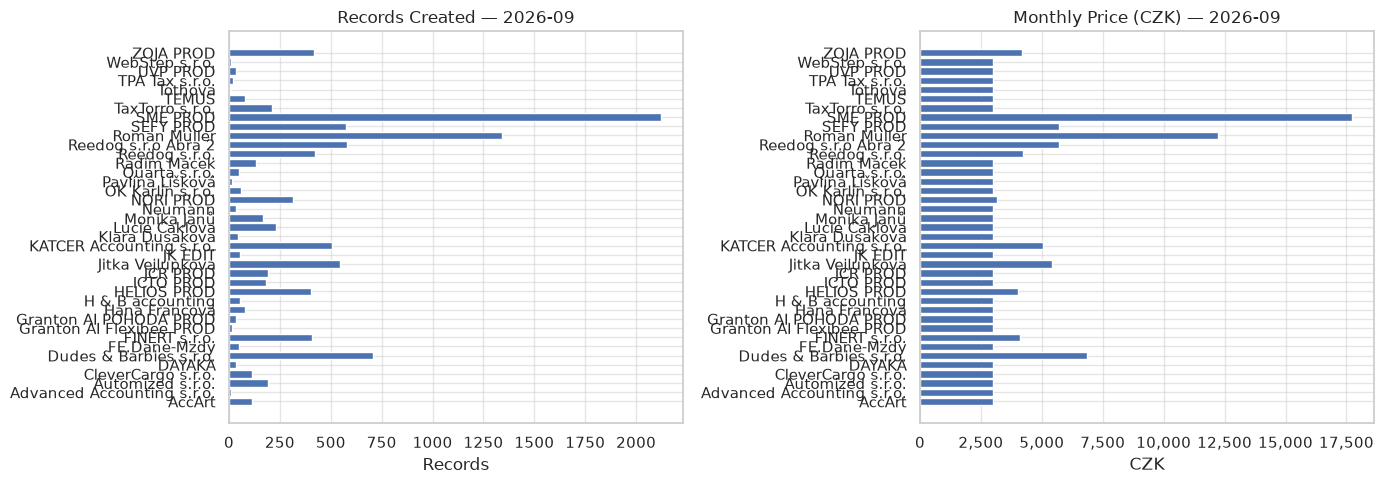

In [6]:
clients = df_summary[df_summary.client_name != 'ZZ TOTAL'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(clients.client_name, clients.records_created)
axes[0].set_title(f'Records Created — {REPORT_YEAR}-{REPORT_MONTH:02d}')
axes[0].set_xlabel('Records')

axes[1].barh(clients.client_name, clients.monthly_price_czk)
axes[1].set_title(f'Monthly Price (CZK) — {REPORT_YEAR}-{REPORT_MONTH:02d}')
axes[1].set_xlabel('CZK')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

## 3. Month-over-Month Growth

In [7]:
SQL_MOM = f"""
WITH monthly_per_client AS (
    SELECT
        c.name                              AS client_name,
        DATE_TRUNC('month', r.created_at)   AS month,
        COUNT(DISTINCT r.job_harvest_id)    AS jobs_harvested,
        COUNT(r.record_id)                  AS records_created,
        GREATEST(2990,
            CASE
                WHEN COUNT(r.record_id) <= 500  THEN COUNT(r.record_id) * 10
                WHEN COUNT(r.record_id) <= 1000 THEN 5000  + (COUNT(r.record_id) - 500)  * 9
                WHEN COUNT(r.record_id) <= 1500 THEN 9500  + (COUNT(r.record_id) - 1000) * 8
                WHEN COUNT(r.record_id) <= 2000 THEN 13500 + (COUNT(r.record_id) - 1500) * 7
                WHEN COUNT(r.record_id) <= 3000 THEN 17000 + (COUNT(r.record_id) - 2000) * 6
                WHEN COUNT(r.record_id) <= 5000 THEN 23000 + (COUNT(r.record_id) - 3000) * 5
                ELSE NULL
            END
        ) AS monthly_price_czk
    FROM record r
    INNER JOIN client c ON r.client_id = c.client_id
    WHERE r.is_deleted = false
      AND {STATE_FILTER}
    GROUP BY c.name, DATE_TRUNC('month', r.created_at)
)
SELECT
    client_name,
    month,
    records_created,
    monthly_price_czk,
    LAG(records_created)   OVER (PARTITION BY client_name ORDER BY month) AS prev_month_records,
    LAG(monthly_price_czk) OVER (PARTITION BY client_name ORDER BY month) AS prev_month_price_czk,
    ROUND((records_created - LAG(records_created) OVER (PARTITION BY client_name ORDER BY month))
        * 100.0 / NULLIF(LAG(records_created) OVER (PARTITION BY client_name ORDER BY month), 0), 1)
        AS records_growth_pct,
    ROUND((monthly_price_czk - LAG(monthly_price_czk) OVER (PARTITION BY client_name ORDER BY month))
        * 100.0 / NULLIF(LAG(monthly_price_czk) OVER (PARTITION BY client_name ORDER BY month), 0), 1)
        AS revenue_growth_pct
FROM monthly_per_client
ORDER BY client_name, month;
"""

df_mom = query(SQL_MOM)
df_mom['month'] = pd.to_datetime(df_mom['month'], utc=True).dt.normalize().dt.tz_localize(None) + pd.offsets.MonthBegin(0)
df_mom['records_growth_pct'] = pd.to_numeric(df_mom['records_growth_pct'], errors='coerce')
df_mom['revenue_growth_pct'] = pd.to_numeric(df_mom['revenue_growth_pct'], errors='coerce')
df_mom.tail(20)

,client_name,month,records_created,monthly_price_czk,prev_month_records,prev_month_price_czk,records_growth_pct,revenue_growth_pct
197,UVP PROD,2026-03-01,145,2990,32.0,2990.0,353.1,0.0
198,UVP PROD,2026-04-01,88,2990,145.0,2990.0,-39.3,0.0
199,UVP PROD,2026-05-01,10,2990,88.0,2990.0,-88.6,0.0
200,UVP PROD,2026-06-01,135,2990,10.0,2990.0,1250.0,0.0
201,UVP PROD,2026-07-01,76,2990,135.0,2990.0,-43.7,0.0
202,UVP PROD,2026-08-01,29,2990,76.0,2990.0,-61.8,0.0
203,UVP PROD,2026-09-01,33,2990,29.0,2990.0,13.8,0.0
204,VFH ekonomický servis,2026-05-01,16,2990,NaN,NaN,NaN,NaN
205,WebStep s.r.o.,2026-09-01,8,2990,NaN,NaN,NaN,NaN
206,ZÁPECOVÁ FINANCIAL S.R.O.,2026-03-01,226,2990,NaN,NaN,NaN,NaN


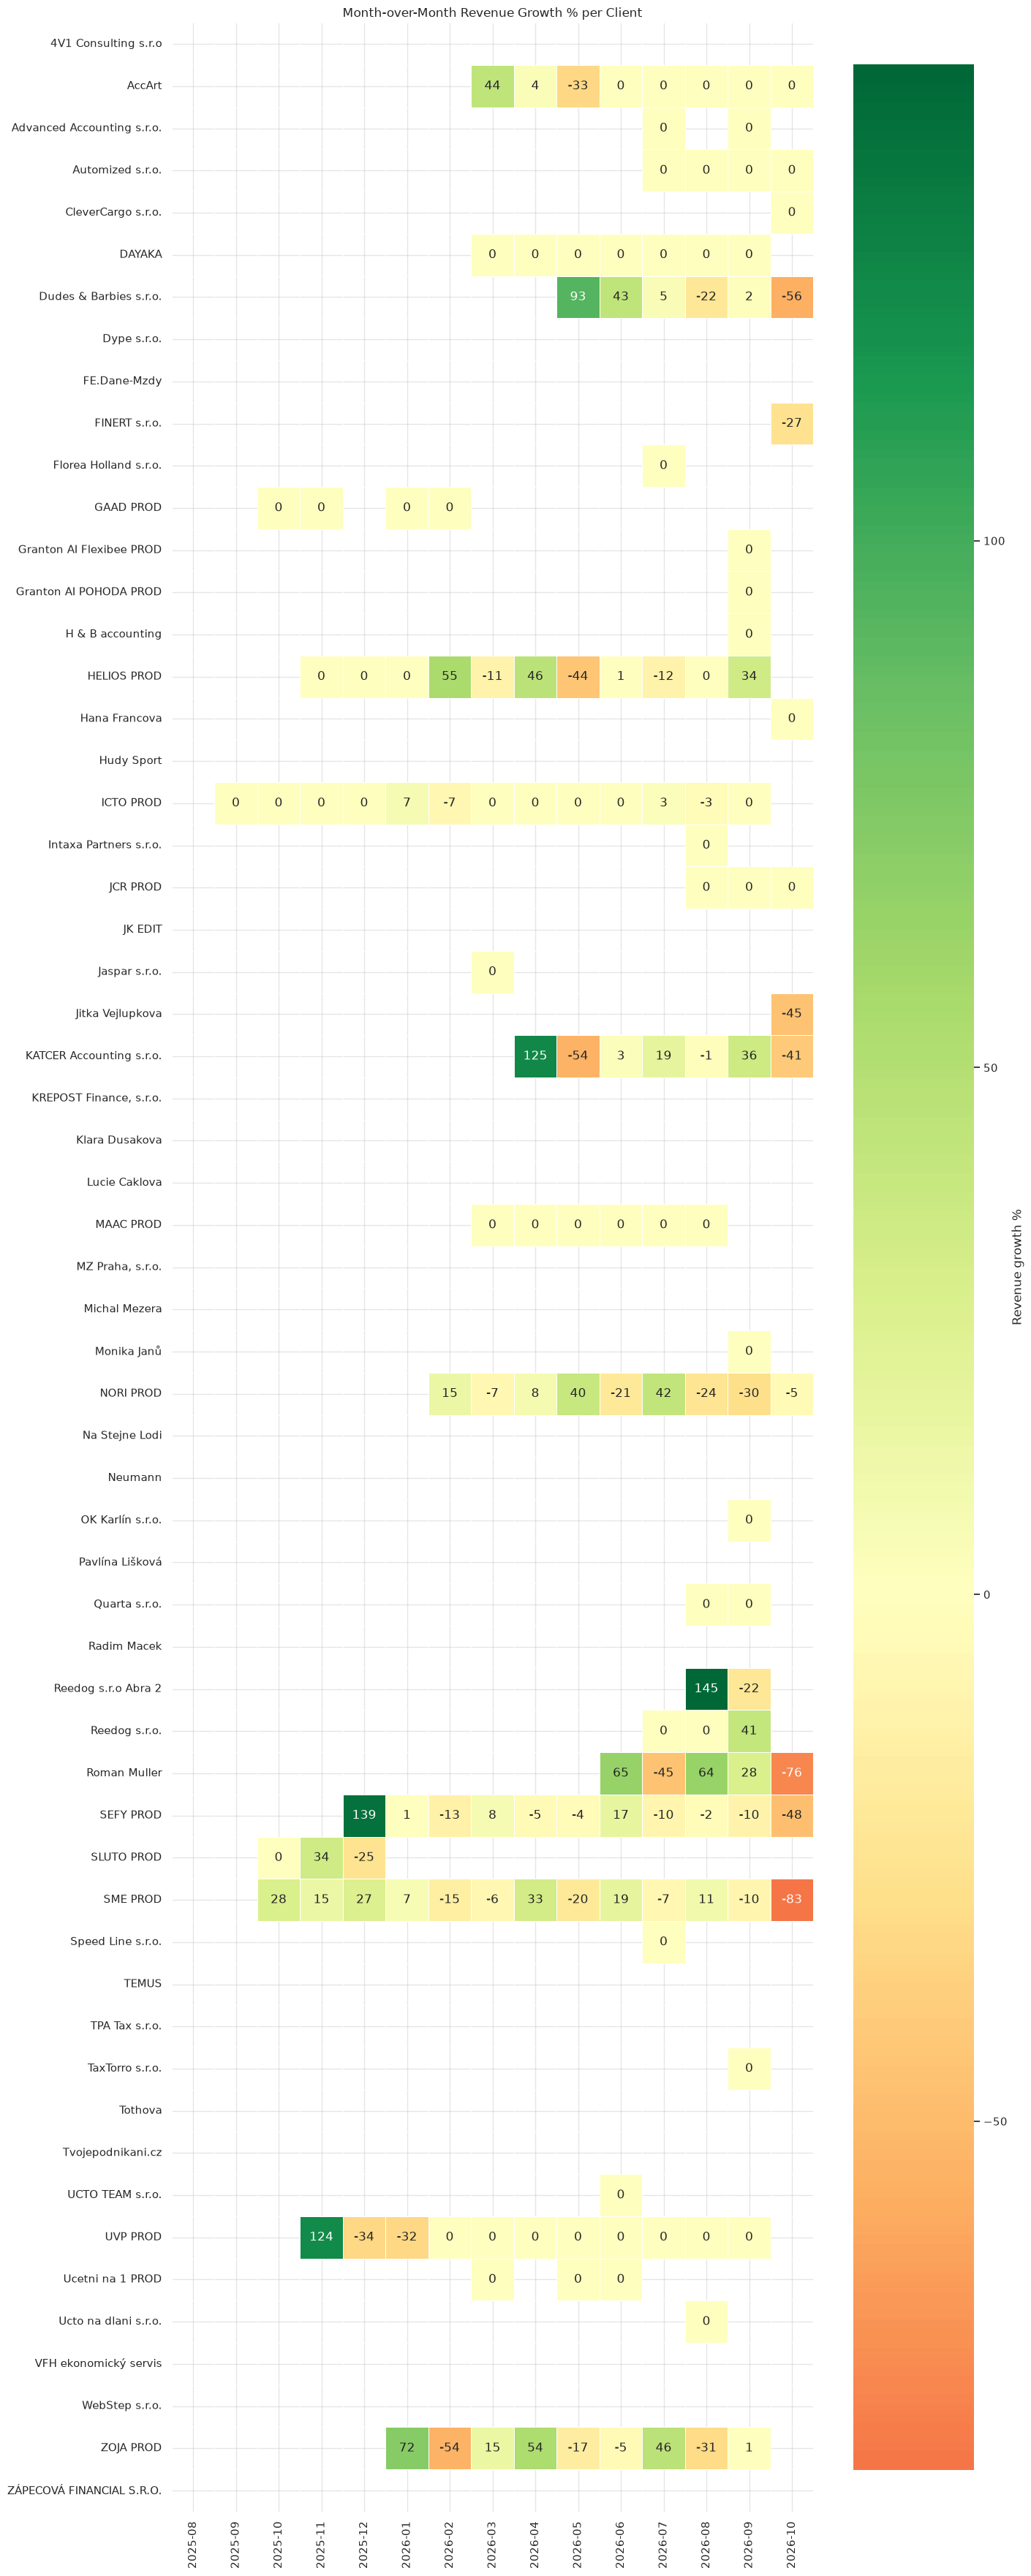

In [8]:
# Heatmap: revenue growth % by client × month
pivot = df_mom.pivot(index='client_name', columns='month', values='revenue_growth_pct')
pivot.columns = pivot.columns.strftime('%Y-%m')

fig, ax = plt.subplots(figsize=(14, max(4, len(pivot) * 0.6)))
sns.heatmap(
    pivot, annot=True, fmt='.0f', center=0, cmap='RdYlGn',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Revenue growth %'}
)
ax.set_title('Month-over-Month Revenue Growth % per Client')
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 4. Revenue Trend (line chart per client)

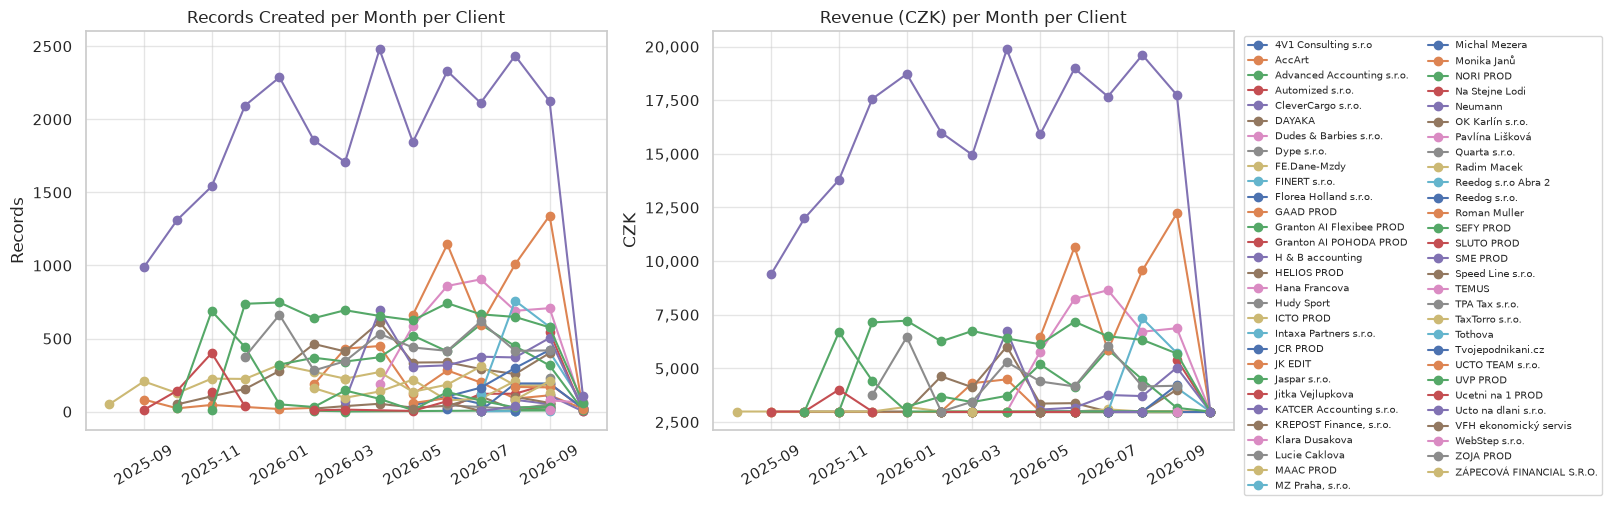

In [9]:
SQL_TREND = f"""
SELECT
    c.name                              AS client_name,
    DATE_TRUNC('month', r.created_at)   AS month,
    COUNT(r.record_id)                  AS records_created,
    GREATEST(2990,
        CASE
            WHEN COUNT(r.record_id) <= 500  THEN COUNT(r.record_id) * 10
            WHEN COUNT(r.record_id) <= 1000 THEN 5000  + (COUNT(r.record_id) - 500)  * 9
            WHEN COUNT(r.record_id) <= 1500 THEN 9500  + (COUNT(r.record_id) - 1000) * 8
            WHEN COUNT(r.record_id) <= 2000 THEN 13500 + (COUNT(r.record_id) - 1500) * 7
            WHEN COUNT(r.record_id) <= 3000 THEN 17000 + (COUNT(r.record_id) - 2000) * 6
            WHEN COUNT(r.record_id) <= 5000 THEN 23000 + (COUNT(r.record_id) - 3000) * 5
            ELSE NULL
        END
    ) AS monthly_price_czk
FROM record r
INNER JOIN client c ON r.client_id = c.client_id
WHERE r.is_deleted = false
  AND {STATE_FILTER}
GROUP BY c.name, DATE_TRUNC('month', r.created_at)
ORDER BY month, client_name;
"""

df_trend = query(SQL_TREND)
df_trend['month'] = pd.to_datetime(df_trend['month'], utc=True).dt.normalize().dt.tz_localize(None) + pd.offsets.MonthBegin(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), layout='constrained')
for client, grp in df_trend.groupby('client_name'):
    axes[0].plot(grp['month'], grp['records_created'], marker='o', label=client)
    axes[1].plot(grp['month'], grp['monthly_price_czk'], marker='o', label=client)
axes[0].set_title('Records Created per Month per Client'); axes[0].set_ylabel('Records')
axes[1].set_title('Revenue (CZK) per Month per Client'); axes[1].set_ylabel('CZK')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')); axes[1].legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left', ncol=2)
for ax in axes: ax.tick_params(axis='x', rotation=30)
plt.show()

## 5. Cumulative YTD Revenue

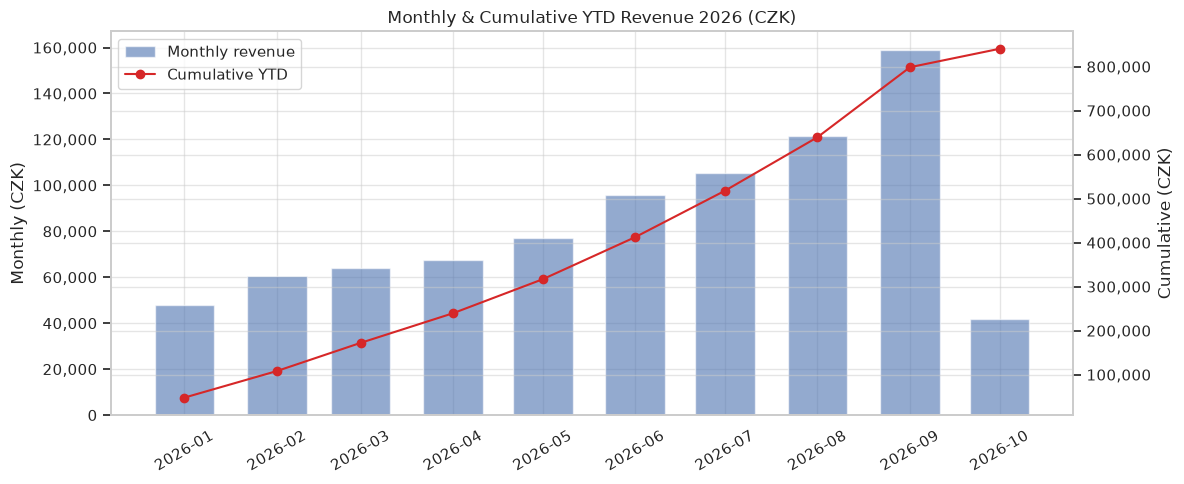

In [10]:
SQL_CUMULATIVE = f"""
WITH per_client_month AS (
    SELECT
        c.name                              AS client_name,
        DATE_TRUNC('month', r.created_at)   AS month,
        GREATEST(2990,
            CASE
                WHEN COUNT(r.record_id) <= 500  THEN COUNT(r.record_id) * 10
                WHEN COUNT(r.record_id) <= 1000 THEN 5000  + (COUNT(r.record_id) - 500)  * 9
                WHEN COUNT(r.record_id) <= 1500 THEN 9500  + (COUNT(r.record_id) - 1000) * 8
                WHEN COUNT(r.record_id) <= 2000 THEN 13500 + (COUNT(r.record_id) - 1500) * 7
                WHEN COUNT(r.record_id) <= 3000 THEN 17000 + (COUNT(r.record_id) - 2000) * 6
                WHEN COUNT(r.record_id) <= 5000 THEN 23000 + (COUNT(r.record_id) - 3000) * 5
                ELSE NULL
            END
        ) AS monthly_price_czk
    FROM record r
    INNER JOIN client c ON r.client_id = c.client_id
    WHERE r.is_deleted = false
      AND {STATE_FILTER}
      AND EXTRACT(YEAR FROM r.created_at) = %(year)s
    GROUP BY c.name, DATE_TRUNC('month', r.created_at)
),
monthly_totals AS (
    SELECT month, SUM(monthly_price_czk) AS monthly_revenue_czk
    FROM per_client_month
    GROUP BY month
)
SELECT
    month,
    monthly_revenue_czk,
    SUM(monthly_revenue_czk) OVER (ORDER BY month) AS cumulative_revenue_czk
FROM monthly_totals
ORDER BY month;
"""

df_cum = query(SQL_CUMULATIVE, {'year': REPORT_YEAR})
df_cum['month'] = pd.to_datetime(df_cum['month'], utc=True).dt.normalize().dt.tz_localize(None) + pd.offsets.MonthBegin(0)
df_cum['monthly_revenue_czk']    = pd.to_numeric(df_cum['monthly_revenue_czk'],    errors='coerce')
df_cum['cumulative_revenue_czk'] = pd.to_numeric(df_cum['cumulative_revenue_czk'], errors='coerce')

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_cum['month'], df_cum['monthly_revenue_czk'], width=20, alpha=0.6, label='Monthly revenue')
ax2 = ax.twinx()
ax2.plot(df_cum['month'], df_cum['cumulative_revenue_czk'], color='tab:red', marker='o', label='Cumulative YTD')
ax.set_title(f'Monthly & Cumulative YTD Revenue {REPORT_YEAR} (CZK)')
ax.set_ylabel('Monthly (CZK)'); ax2.set_ylabel('Cumulative (CZK)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.tick_params(axis='x', rotation=30)
l1, lb1 = ax.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, loc='upper left')
plt.tight_layout(); plt.show()

## 6. Daily Volume Heatmap

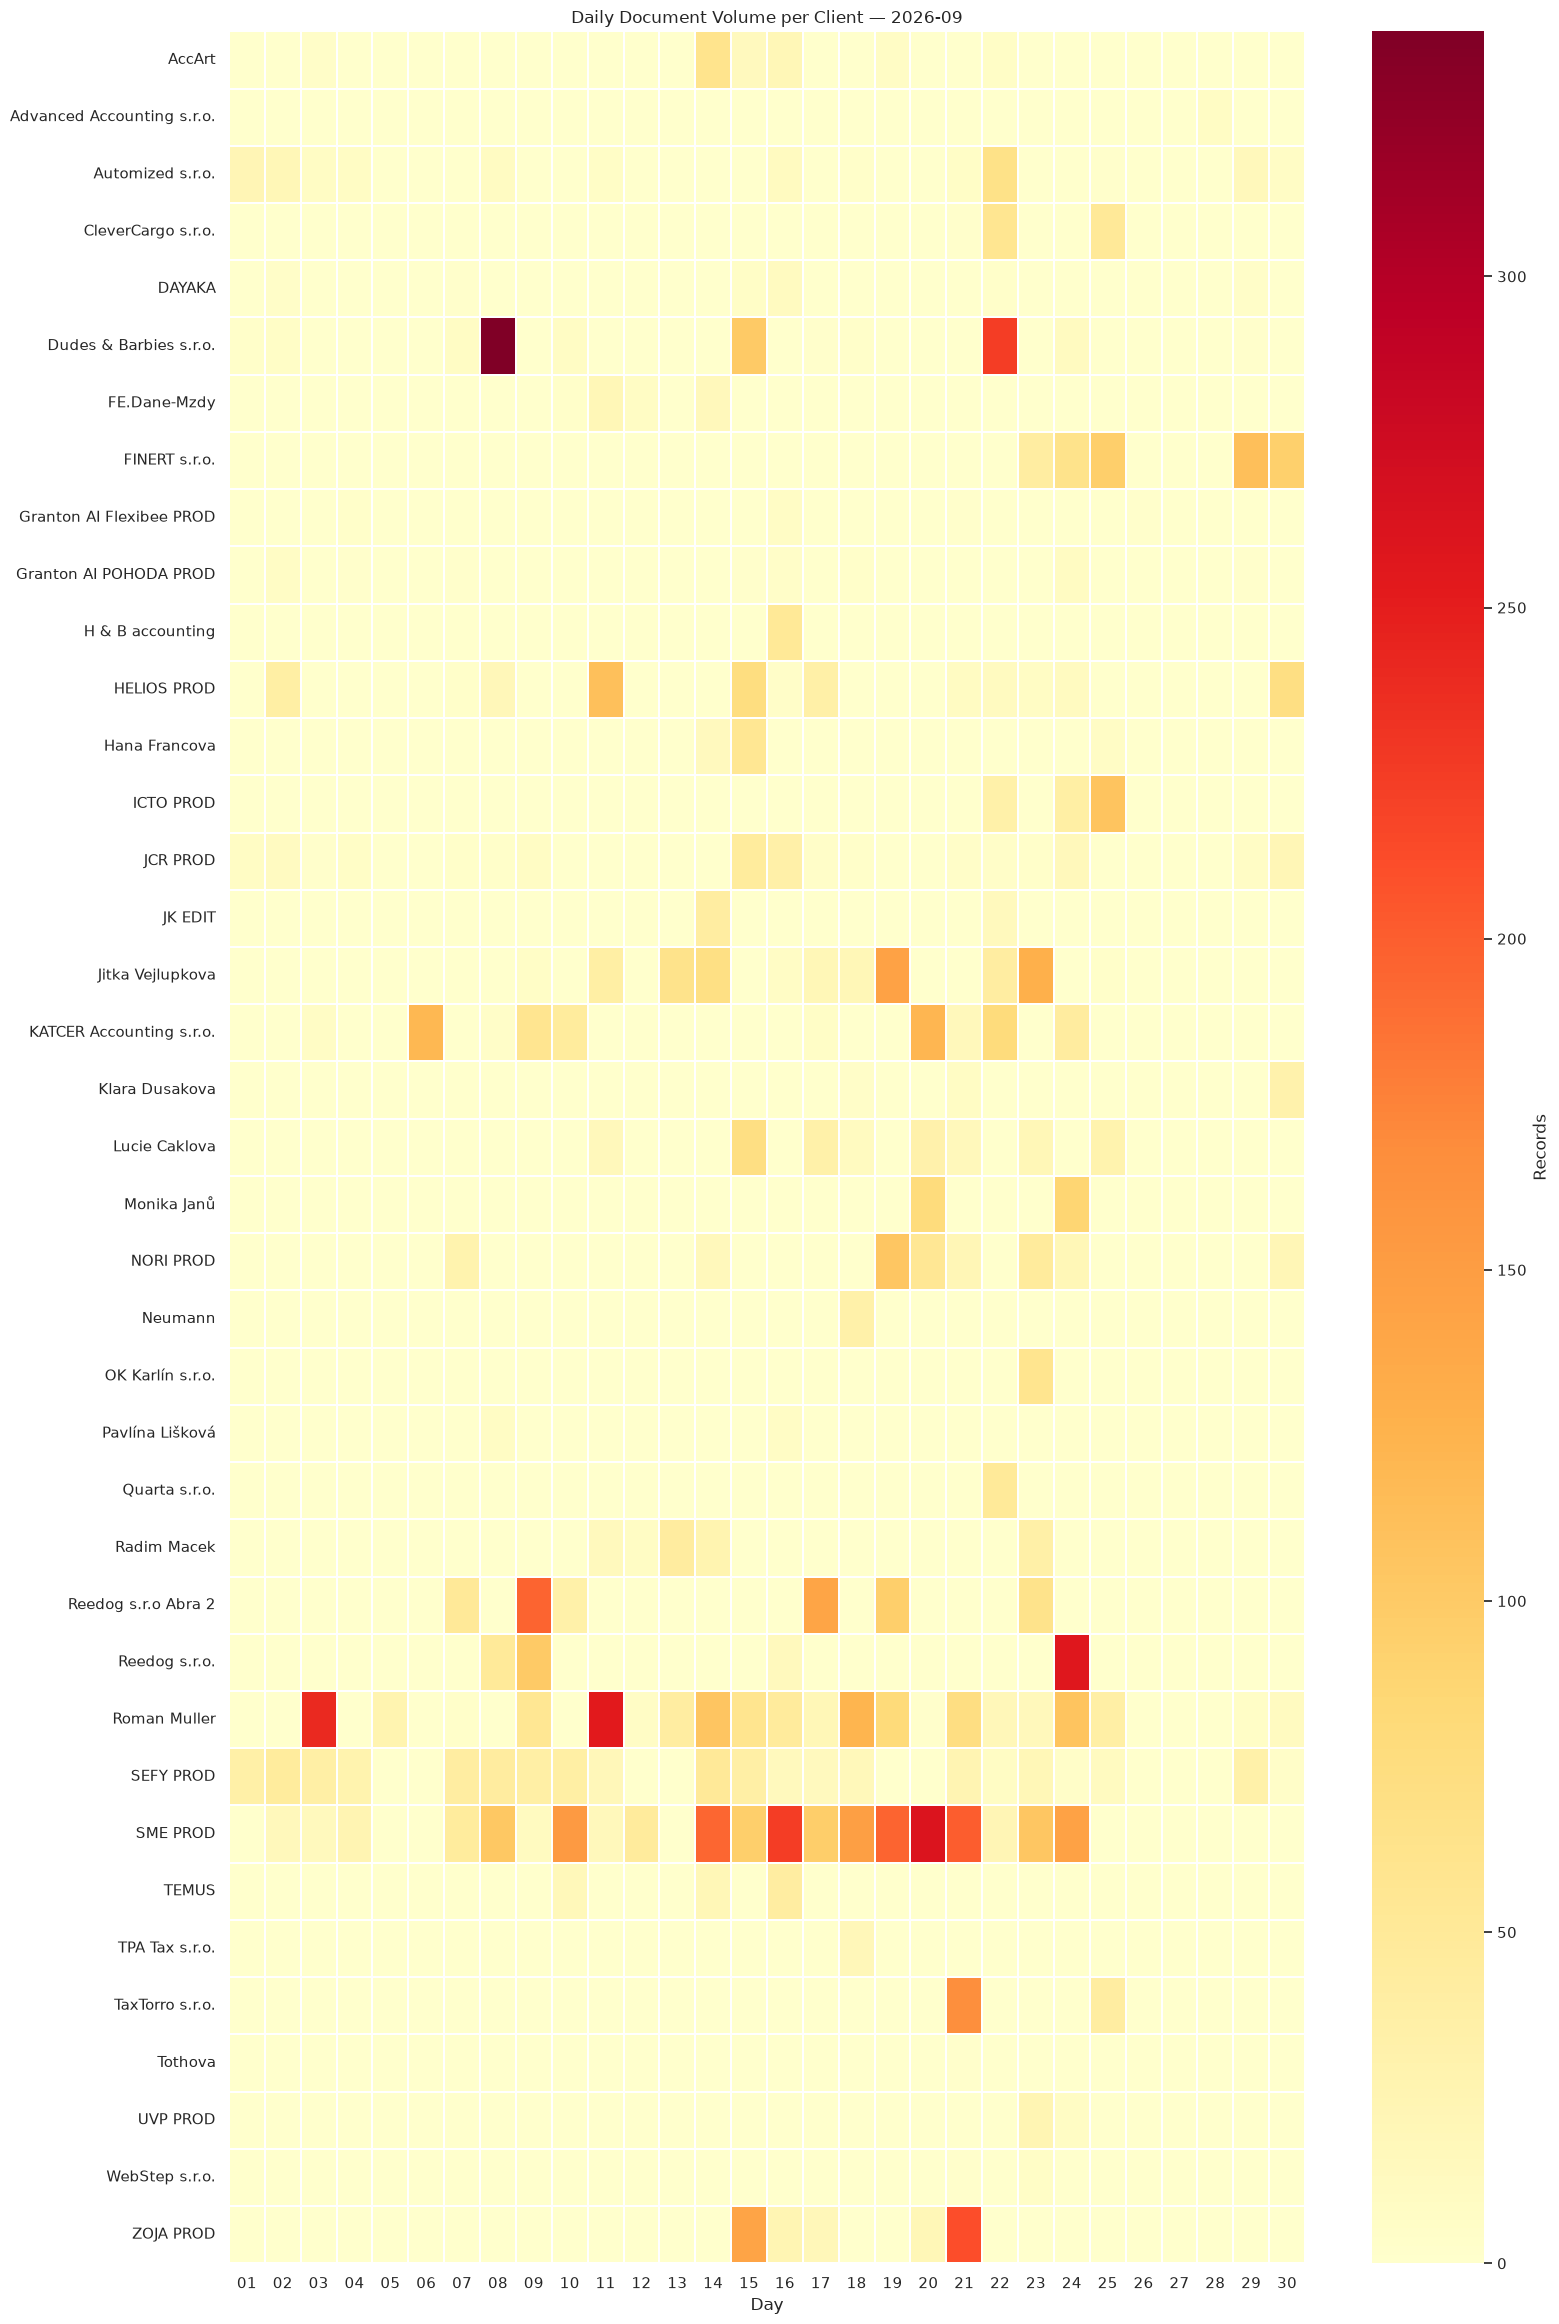

In [11]:
SQL_DAILY = f"""
SELECT
    c.name             AS client_name,
    DATE(r.created_at) AS day,
    COUNT(r.record_id) AS records_created
FROM record r
INNER JOIN client c ON r.client_id = c.client_id
WHERE r.is_deleted = false
  AND {STATE_FILTER}
  AND EXTRACT(YEAR  FROM r.created_at) = %(year)s
  AND EXTRACT(MONTH FROM r.created_at) = %(month)s
GROUP BY c.name, DATE(r.created_at)
ORDER BY day, client_name;
"""

df_daily = query(SQL_DAILY, {'year': REPORT_YEAR, 'month': REPORT_MONTH})
df_daily['day'] = pd.to_datetime(df_daily['day']).dt.normalize()

pivot_daily = df_daily.pivot_table(index='client_name', columns='day', values='records_created', fill_value=0)
pivot_daily.columns = pivot_daily.columns.strftime('%d')

fig, ax = plt.subplots(figsize=(16, max(4, len(pivot_daily) * 0.6)))
sns.heatmap(pivot_daily, cmap='YlOrRd', linewidths=0.3, ax=ax, cbar_kws={'label': 'Records'})
ax.set_title(f'Daily Document Volume per Client — {REPORT_YEAR}-{REPORT_MONTH:02d}')
ax.set_xlabel('Day'); ax.set_ylabel('')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## 7. Harvest Job Efficiency

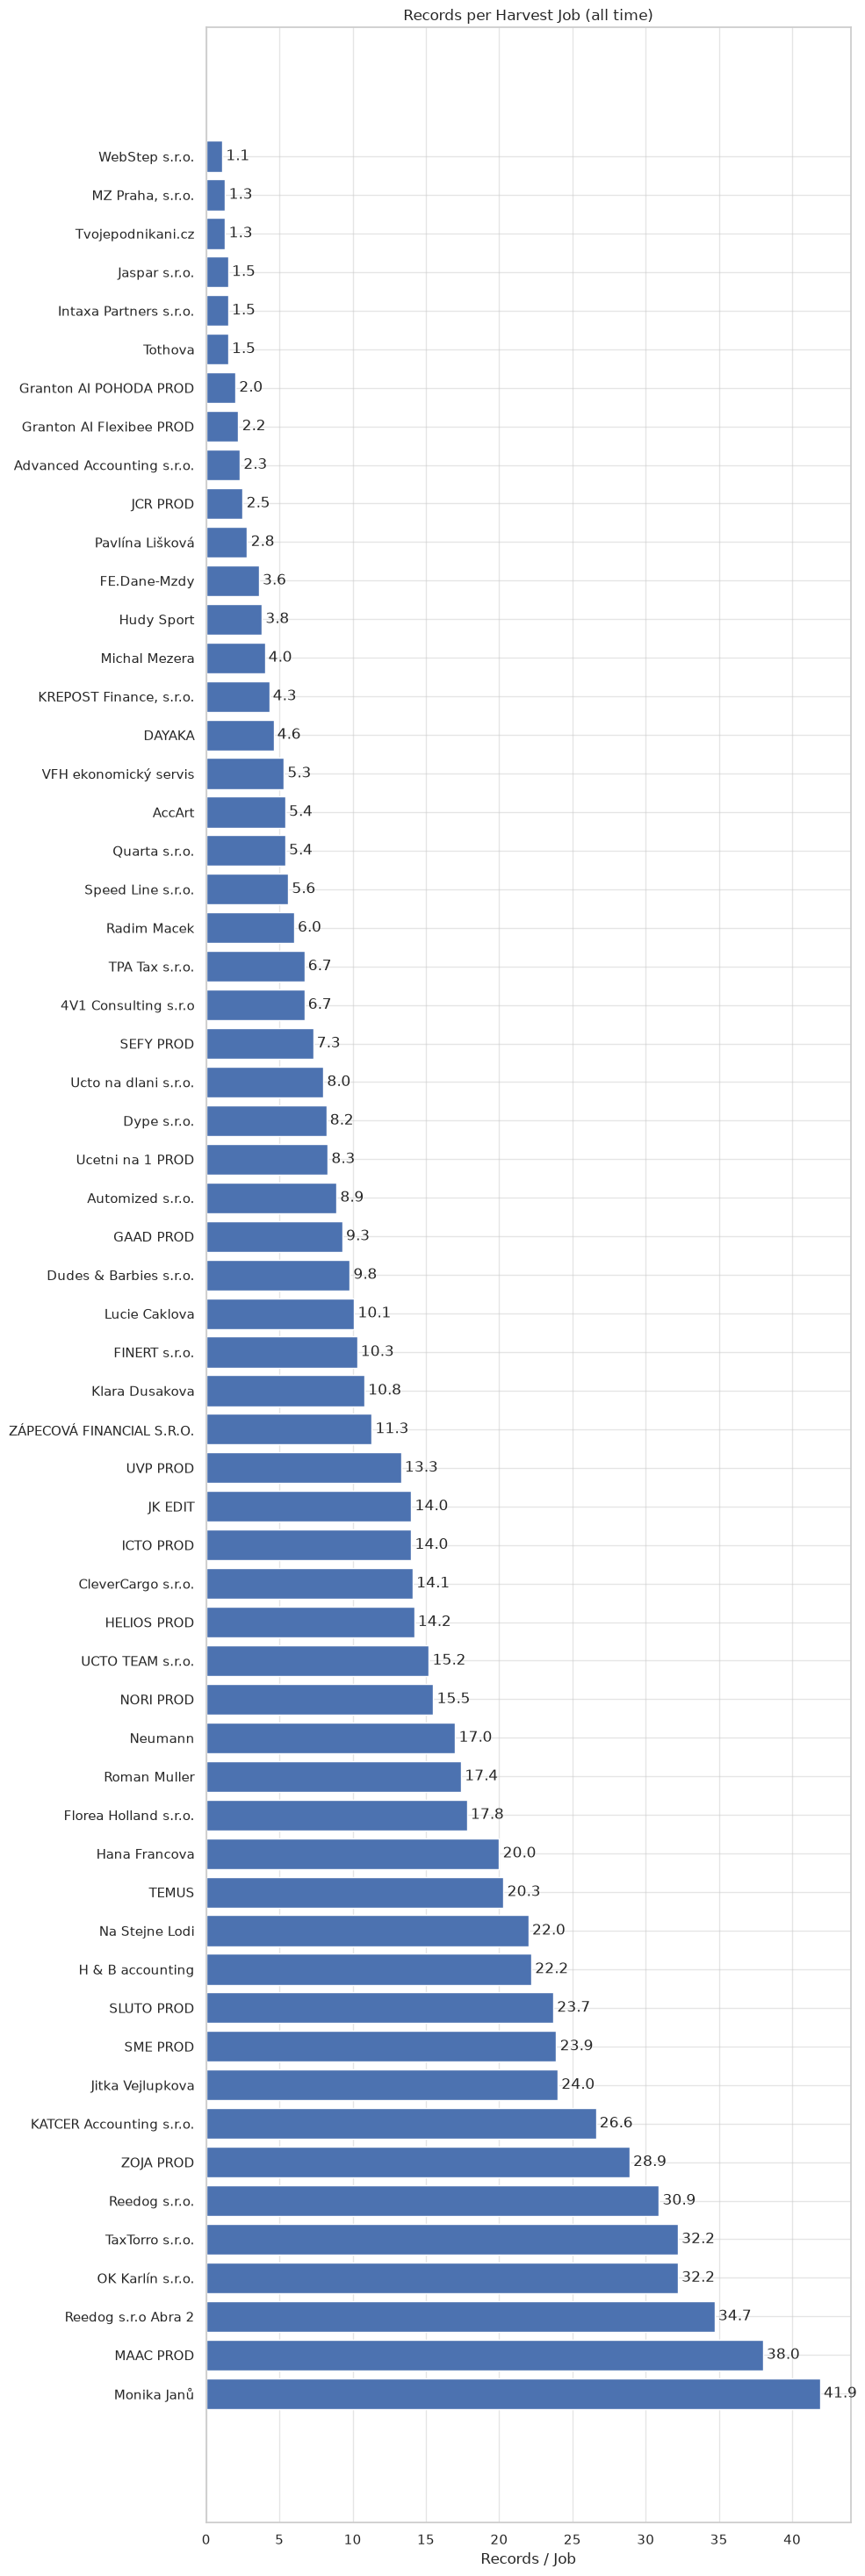

,client_name,jobs_harvested,records_created,records_per_job
0,Monika Janů,8,335,41.9
1,MAAC PROD,26,988,38.0
2,Reedog s.r.o Abra 2,42,1457,34.7
3,OK Karlín s.r.o.,5,161,32.2
4,TaxTorro s.r.o.,9,290,32.2
5,Reedog s.r.o.,30,927,30.9
6,ZOJA PROD,156,4505,28.9
7,KATCER Accounting s.r.o.,100,2657,26.6
8,Jitka Vejlupkova,23,552,24.0
9,SME PROD,1055,25218,23.9


In [12]:
SQL_EFFICIENCY = f"""
SELECT
    c.name                                          AS client_name,
    COUNT(DISTINCT r.job_harvest_id)                AS jobs_harvested,
    COUNT(r.record_id)                              AS records_created,
    ROUND(COUNT(r.record_id)::numeric /
          NULLIF(COUNT(DISTINCT r.job_harvest_id), 0), 1) AS records_per_job
FROM record r
INNER JOIN client c ON r.client_id = c.client_id
WHERE r.is_deleted = false
  AND {STATE_FILTER}
GROUP BY c.name
ORDER BY records_per_job DESC;
"""

df_eff = query(SQL_EFFICIENCY)
df_eff['records_per_job'] = pd.to_numeric(df_eff['records_per_job'], errors='coerce')

fig, ax = plt.subplots(figsize=(10, max(4, len(df_eff) * 0.5)))
bars = ax.barh(df_eff['client_name'], df_eff['records_per_job'])
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.set_title('Records per Harvest Job (all time)'); ax.set_xlabel('Records / Job')
plt.tight_layout(); plt.show()
df_eff

## 8. Pareto — Top Clients by Volume

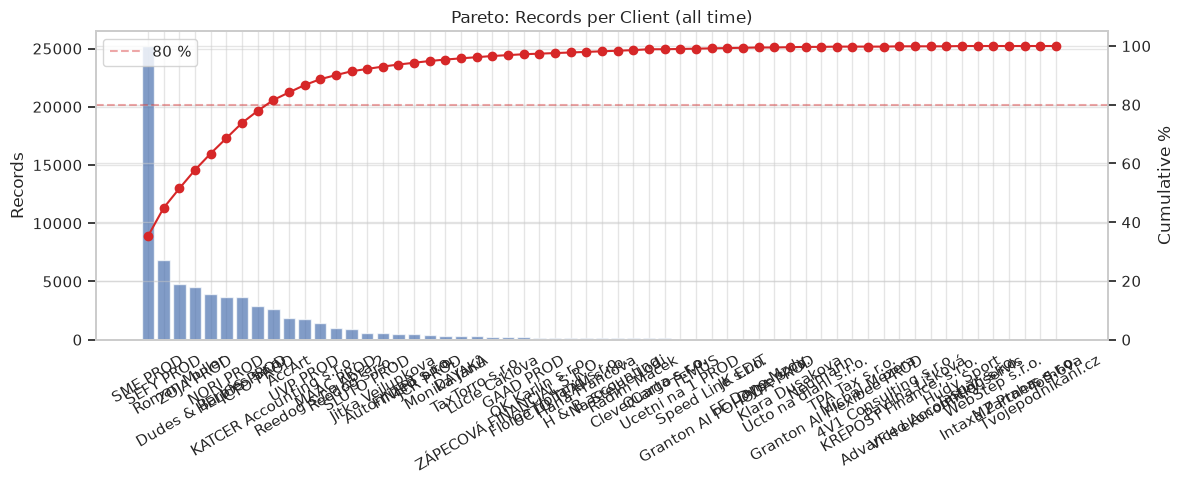

,rank,client_name,records_created,pct_of_total,cumulative_pct
0,1,SME PROD,25218,35.3,35.3
1,2,SEFY PROD,6803,9.5,44.9
2,3,Roman Muller,4766,6.7,51.5
3,4,ZOJA PROD,4505,6.3,57.8
4,5,Dudes & Barbies s.r.o.,3963,5.6,63.4
5,6,NORI PROD,3710,5.2,68.6
6,7,HELIOS PROD,3701,5.2,73.8
7,8,ICTO PROD,2916,4.1,77.9
8,9,KATCER Accounting s.r.o.,2657,3.7,81.6
9,10,AccArt,1890,2.6,84.2


In [13]:
SQL_PARETO = f"""
WITH per_client AS (
    SELECT
        c.name              AS client_name,
        COUNT(r.record_id)  AS records_created
    FROM record r
    INNER JOIN client c ON r.client_id = c.client_id
    WHERE r.is_deleted = false
      AND {STATE_FILTER}
    GROUP BY c.name
),
ranked AS (
    SELECT
        client_name,
        records_created,
        RANK() OVER (ORDER BY records_created DESC) AS rank,
        ROUND(records_created * 100.0 / SUM(records_created) OVER (), 1) AS pct_of_total,
        ROUND(SUM(records_created) OVER (ORDER BY records_created DESC)
            * 100.0 / SUM(records_created) OVER (), 1) AS cumulative_pct
    FROM per_client
)
SELECT rank, client_name, records_created, pct_of_total, cumulative_pct
FROM ranked
ORDER BY rank;
"""

df_pareto = query(SQL_PARETO)
df_pareto['pct_of_total']   = pd.to_numeric(df_pareto['pct_of_total'],   errors='coerce')
df_pareto['cumulative_pct'] = pd.to_numeric(df_pareto['cumulative_pct'], errors='coerce')

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_pareto['client_name'], df_pareto['records_created'], alpha=0.7)
ax2 = ax.twinx()
ax2.plot(df_pareto['client_name'], df_pareto['cumulative_pct'], color='tab:red', marker='o')
ax2.axhline(80, color='tab:red', linestyle='--', alpha=0.4, label='80 %')
ax.set_title('Pareto: Records per Client (all time)'); ax.set_ylabel('Records')
ax2.set_ylabel('Cumulative %'); ax2.set_ylim(0, 105)
ax.tick_params(axis='x', rotation=30); ax2.legend()
plt.tight_layout(); plt.show()
df_pareto

## 9. LLM Cost per Client per Month

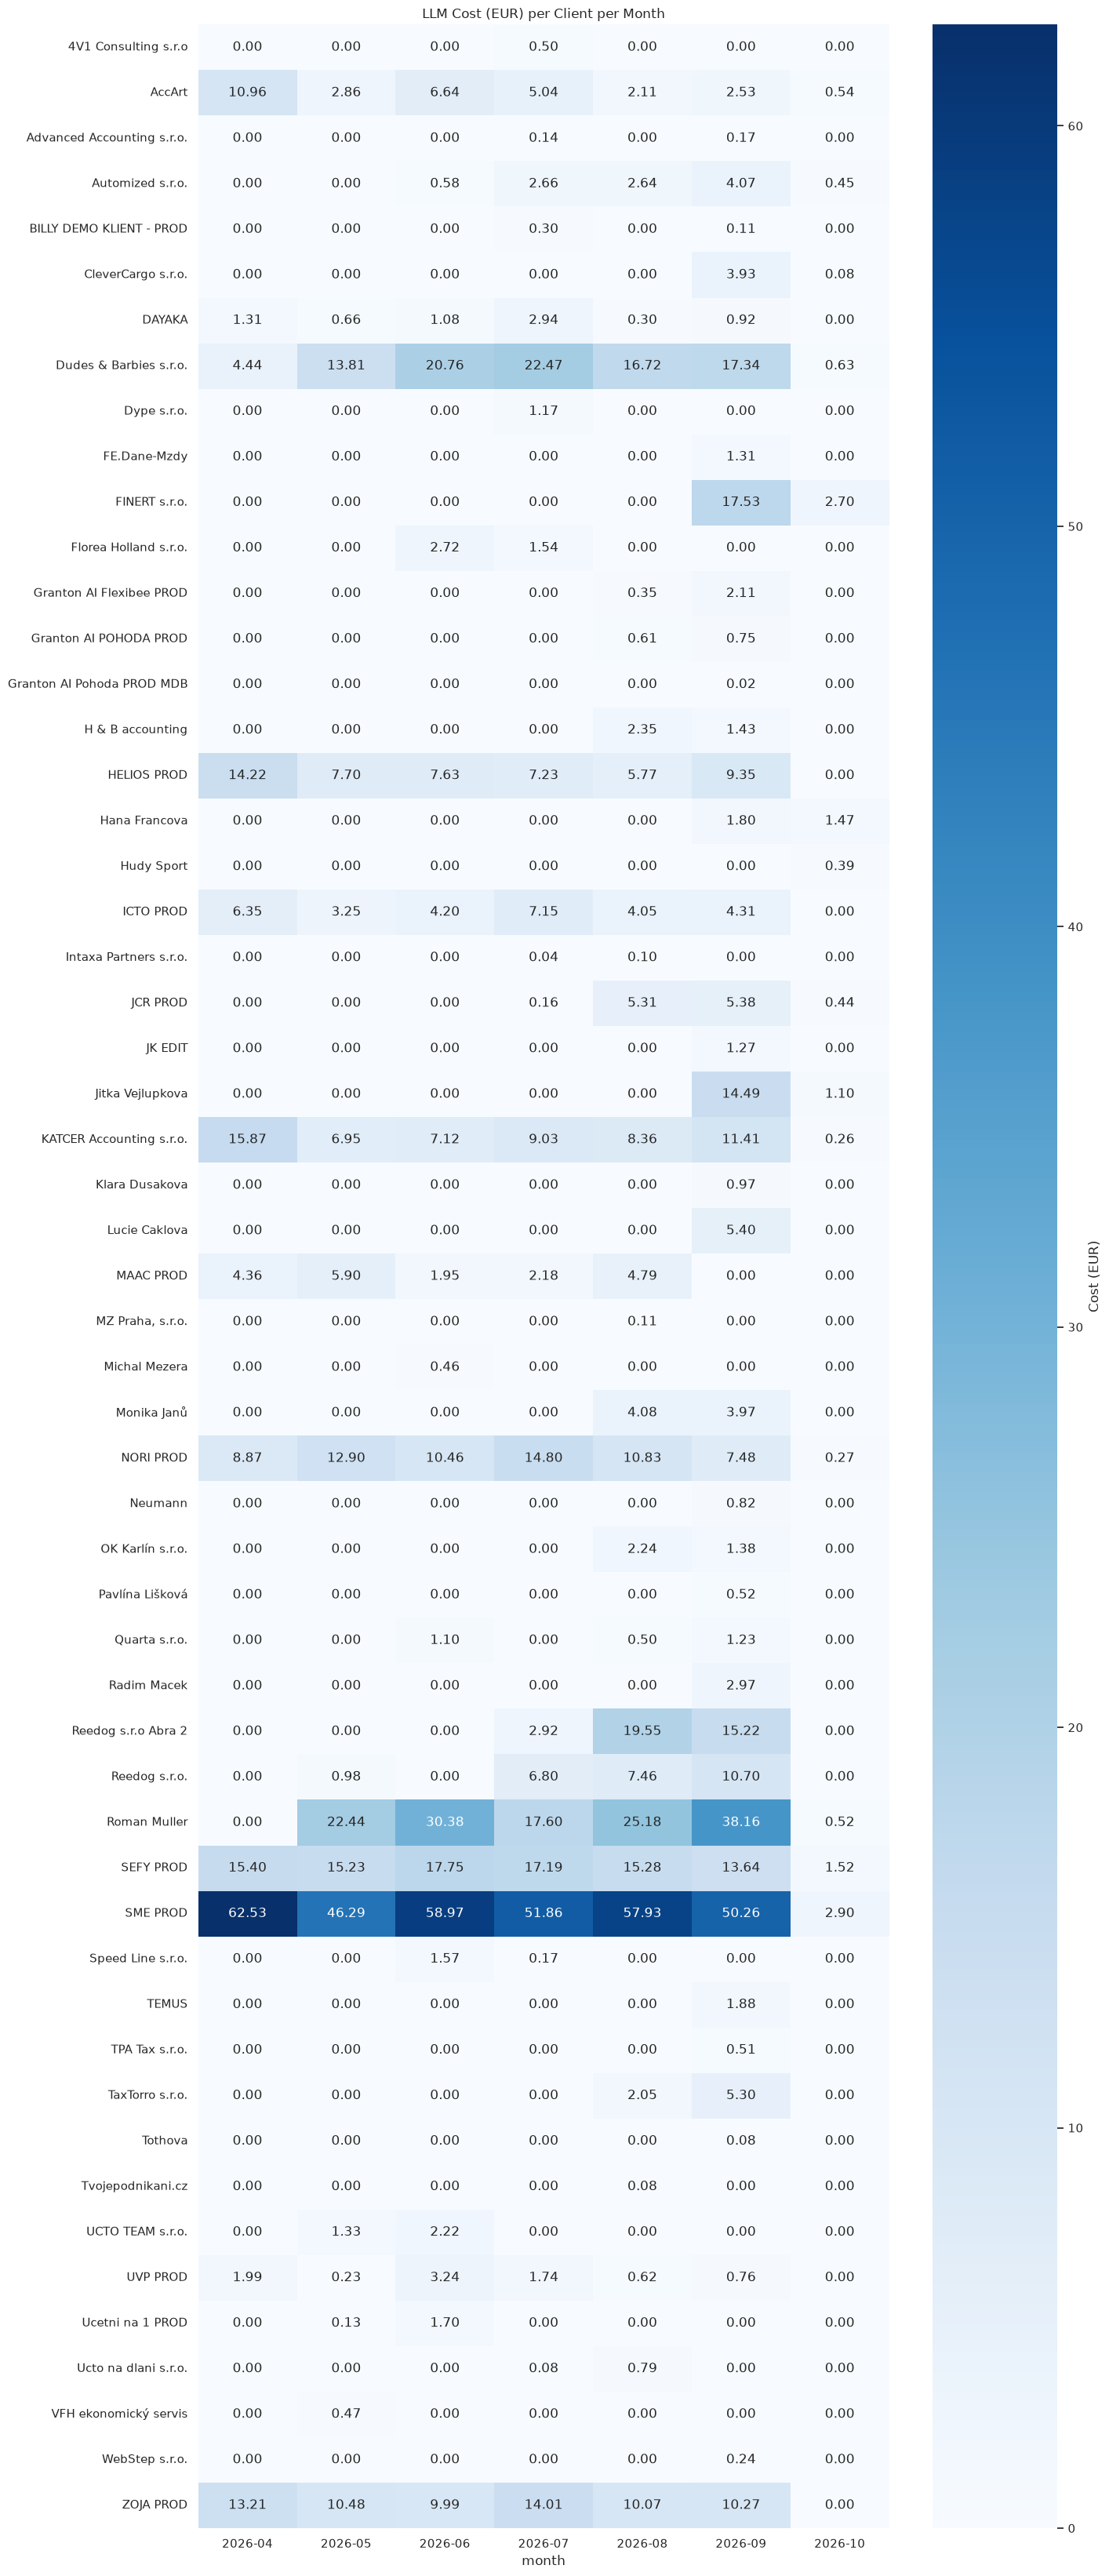

,client_name,month,records_processed,llm_calls,total_prompt_tokens,total_completion_tokens,total_tokens,total_cost_eur
0,SME PROD,2026-10-01,117,117,1192471,47326,1239797,2.9034
1,FINERT s.r.o.,2026-10-01,112,113,1115680,41839,1157519,2.6959
2,SEFY PROD,2026-10-01,68,68,621721,25689,647410,1.5223
3,Hana Francova,2026-10-01,67,67,597170,26124,623294,1.4744
4,Jitka Vejlupkova,2026-10-01,46,46,449820,18078,467898,1.0971
...,...,...,...,...,...,...,...,...
152,ICTO PROD,2026-04-01,284,284,2390683,157508,2548191,6.3475
153,Dudes & Barbies s.r.o.,2026-04-01,198,201,1653093,115084,1768177,4.4410
154,MAAC PROD,2026-04-01,167,168,1659140,103656,1762796,4.3576
155,UVP PROD,2026-04-01,96,96,734773,53017,787790,1.9896


In [14]:
SQL_LLM_COST = f"""
WITH cost_per_call AS (
    SELECT
        lu.record_id,
        lu.invoked_at,
        lu.prompt_tokens,
        lu.completion_tokens,
        lu.total_tokens,
        lu.elapsed_time_seconds,
        lu.model_name,
        (lu.prompt_tokens     * {PRICE_INPUT}  / 1000000.0 +
         lu.completion_tokens * {PRICE_OUTPUT} / 1000000.0) AS cost_eur
    FROM llm_data.llm_usage lu
)
SELECT
    c.name                              AS client_name,
    DATE_TRUNC('month', cpc.invoked_at) AS month,
    COUNT(DISTINCT r.record_id)         AS records_processed,
    COUNT(cpc.record_id)                AS llm_calls,
    SUM(cpc.prompt_tokens)              AS total_prompt_tokens,
    SUM(cpc.completion_tokens)          AS total_completion_tokens,
    SUM(cpc.total_tokens)               AS total_tokens,
    ROUND(SUM(cpc.cost_eur)::numeric, 4) AS total_cost_eur
FROM cost_per_call cpc
INNER JOIN record r ON cpc.record_id = r.record_id
INNER JOIN client c ON r.client_id   = c.client_id
GROUP BY c.name, DATE_TRUNC('month', cpc.invoked_at)
ORDER BY month DESC, total_cost_eur DESC;
"""

df_llm = query(SQL_LLM_COST)
df_llm['month'] = pd.to_datetime(df_llm['month'], utc=True).dt.normalize().dt.tz_localize(None) + pd.offsets.MonthBegin(0)
df_llm['total_cost_eur'] = pd.to_numeric(df_llm['total_cost_eur'], errors='coerce')

pivot_llm = df_llm.pivot_table(index='client_name', columns='month', values='total_cost_eur', fill_value=0)
pivot_llm.columns = pivot_llm.columns.strftime('%Y-%m')

fig, ax = plt.subplots(figsize=(14, max(4, len(pivot_llm) * 0.6)))
sns.heatmap(pivot_llm, annot=True, fmt='.2f', cmap='Blues', ax=ax, cbar_kws={'label': 'Cost (EUR)'})
ax.set_title('LLM Cost (EUR) per Client per Month')
ax.set_ylabel('')
plt.tight_layout()
plt.show()
df_llm

## 10. Model Usage Over Time

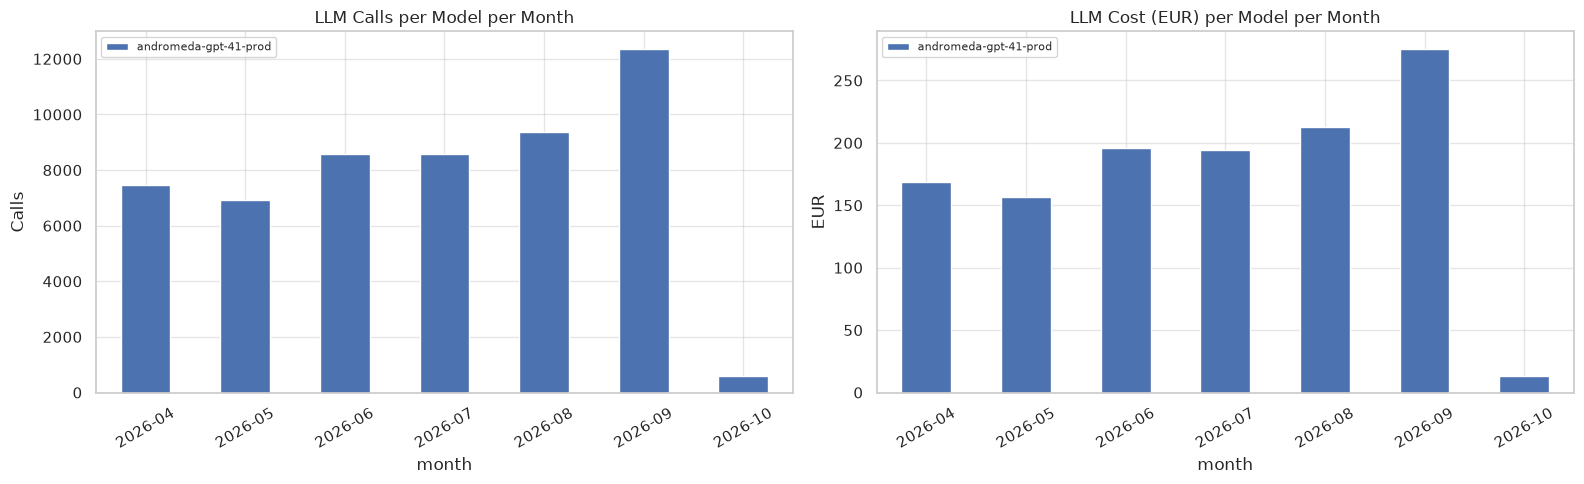

,month,model_name,llm_calls,total_tokens,avg_elapsed_sec,total_cost_eur
0,2026-10-01,andromeda-gpt-41-prod,584,5645841,3.86,13.2627
1,2026-09-01,andromeda-gpt-41-prod,12372,116728484,4.37,275.5790
2,2026-08-01,andromeda-gpt-41-prod,9382,85415758,6.13,212.5225
3,2026-07-01,andromeda-gpt-41-prod,8583,78351013,5.80,194.6447
4,2026-06-01,andromeda-gpt-41-prod,8569,78551688,6.01,195.5147
5,2026-05-01,andromeda-gpt-41-prod,6920,62964913,5.75,156.7765
6,2026-04-01,andromeda-gpt-41-prod,7474,67719038,6.34,168.5197


In [15]:
SQL_MODELS = f"""
SELECT
    DATE_TRUNC('month', lu.invoked_at)              AS month,
    lu.model_name,
    COUNT(lu.usage_id)                              AS llm_calls,
    SUM(lu.total_tokens)                            AS total_tokens,
    ROUND(AVG(lu.elapsed_time_seconds)::numeric, 2) AS avg_elapsed_sec,
    ROUND((SUM(lu.prompt_tokens)     * {PRICE_INPUT}  / 1000000.0 +
           SUM(lu.completion_tokens) * {PRICE_OUTPUT} / 1000000.0)::numeric, 4) AS total_cost_eur
FROM llm_data.llm_usage lu
GROUP BY DATE_TRUNC('month', lu.invoked_at), lu.model_name
ORDER BY month DESC, llm_calls DESC;
"""

df_models = query(SQL_MODELS)
df_models['month'] = pd.to_datetime(df_models['month'], utc=True).dt.normalize().dt.tz_localize(None) + pd.offsets.MonthBegin(0)
for col in ('avg_elapsed_sec', 'total_cost_eur'):
    df_models[col] = pd.to_numeric(df_models[col], errors='coerce')

pivot_calls = df_models.pivot_table(index='month', columns='model_name', values='llm_calls', fill_value=0)
pivot_calls.index = pivot_calls.index.strftime('%Y-%m')   # categorical labels -> avoids ts-plot freq error

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
pivot_calls.plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title('LLM Calls per Model per Month'); axes[0].set_ylabel('Calls')
axes[0].tick_params(axis='x', rotation=30); axes[0].legend(fontsize=8)

pivot_cost = df_models.pivot_table(index='month', columns='model_name', values='total_cost_eur', fill_value=0)
pivot_cost.index = pivot_cost.index.strftime('%Y-%m')
pivot_cost.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('LLM Cost (EUR) per Model per Month'); axes[1].set_ylabel('EUR')
axes[1].tick_params(axis='x', rotation=30); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()
df_models

## 11. Monthly LLM Cost Trend (all clients)

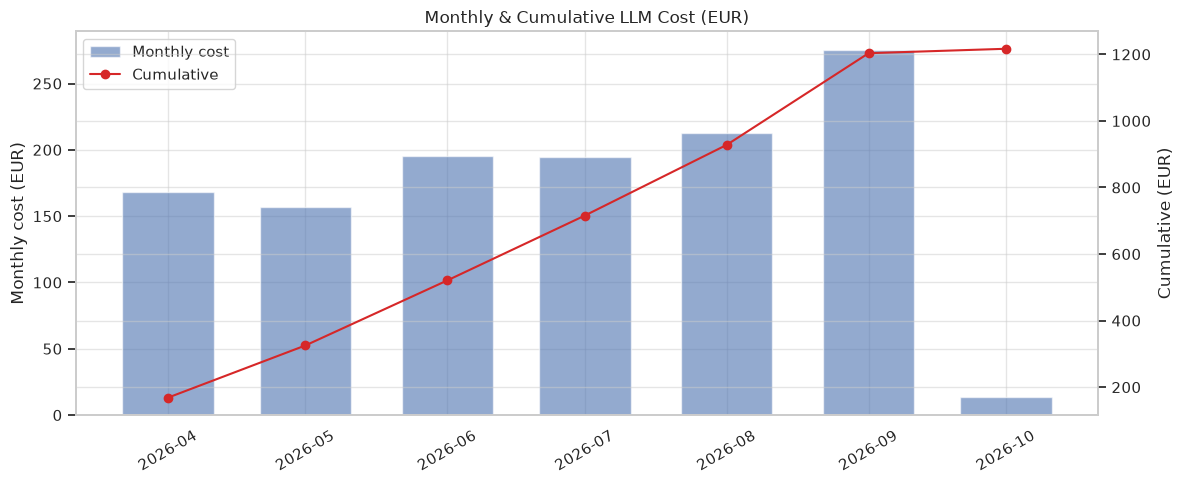

,month,prompt_tokens,completion_tokens,total_tokens,llm_calls,cost_eur,cumulative_cost_eur
0,2026-04-01,63559587,4159451,67719038,7474,168.5197,168.5197
1,2026-05-01,59083591,3881322,62964913,6920,156.7765,325.2962
2,2026-06-01,73720878,4830810,78551688,8569,195.5147,520.8109
3,2026-07-01,73591273,4759740,78351013,8583,194.6447,715.4556
4,2026-08-01,80174993,5240765,85415758,9382,212.5225,927.9781
5,2026-09-01,111920670,4807814,116728484,12372,275.5790,1203.5571
6,2026-10-01,5423807,222034,5645841,584,13.2627,1216.8198


In [16]:
SQL_LLM_TREND = f"""
WITH monthly AS (
    SELECT
        DATE_TRUNC('month', lu.invoked_at)  AS month,
        SUM(lu.prompt_tokens)               AS prompt_tokens,
        SUM(lu.completion_tokens)           AS completion_tokens,
        SUM(lu.total_tokens)                AS total_tokens,
        COUNT(lu.usage_id)                  AS llm_calls,
        ROUND((SUM(lu.prompt_tokens)     * {PRICE_INPUT}  / 1000000.0 +
               SUM(lu.completion_tokens) * {PRICE_OUTPUT} / 1000000.0)::numeric, 4) AS cost_eur
    FROM llm_data.llm_usage lu
    GROUP BY DATE_TRUNC('month', lu.invoked_at)
)
SELECT
    month,
    prompt_tokens,
    completion_tokens,
    total_tokens,
    llm_calls,
    cost_eur,
    ROUND(SUM(cost_eur) OVER (ORDER BY month)::numeric, 4) AS cumulative_cost_eur
FROM monthly
ORDER BY month;
"""

df_llm_trend = query(SQL_LLM_TREND)
df_llm_trend['month'] = pd.to_datetime(df_llm_trend['month'], utc=True).dt.normalize().dt.tz_localize(None) + pd.offsets.MonthBegin(0)
df_llm_trend['cost_eur'] = pd.to_numeric(df_llm_trend['cost_eur'], errors='coerce')
df_llm_trend['cumulative_cost_eur'] = pd.to_numeric(df_llm_trend['cumulative_cost_eur'], errors='coerce')

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_llm_trend['month'], df_llm_trend['cost_eur'], width=20, alpha=0.6, label='Monthly cost')
ax2 = ax.twinx()
ax2.plot(df_llm_trend['month'], df_llm_trend['cumulative_cost_eur'], color='tab:red', marker='o', label='Cumulative')
ax.set_title('Monthly & Cumulative LLM Cost (EUR)')
ax.set_ylabel('Monthly cost (EUR)'); ax2.set_ylabel('Cumulative (EUR)')
ax.tick_params(axis='x', rotation=30)
l1, lb1 = ax.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, loc='upper left')
plt.tight_layout(); plt.show()
df_llm_trend

## 12. Pipeline Funnel

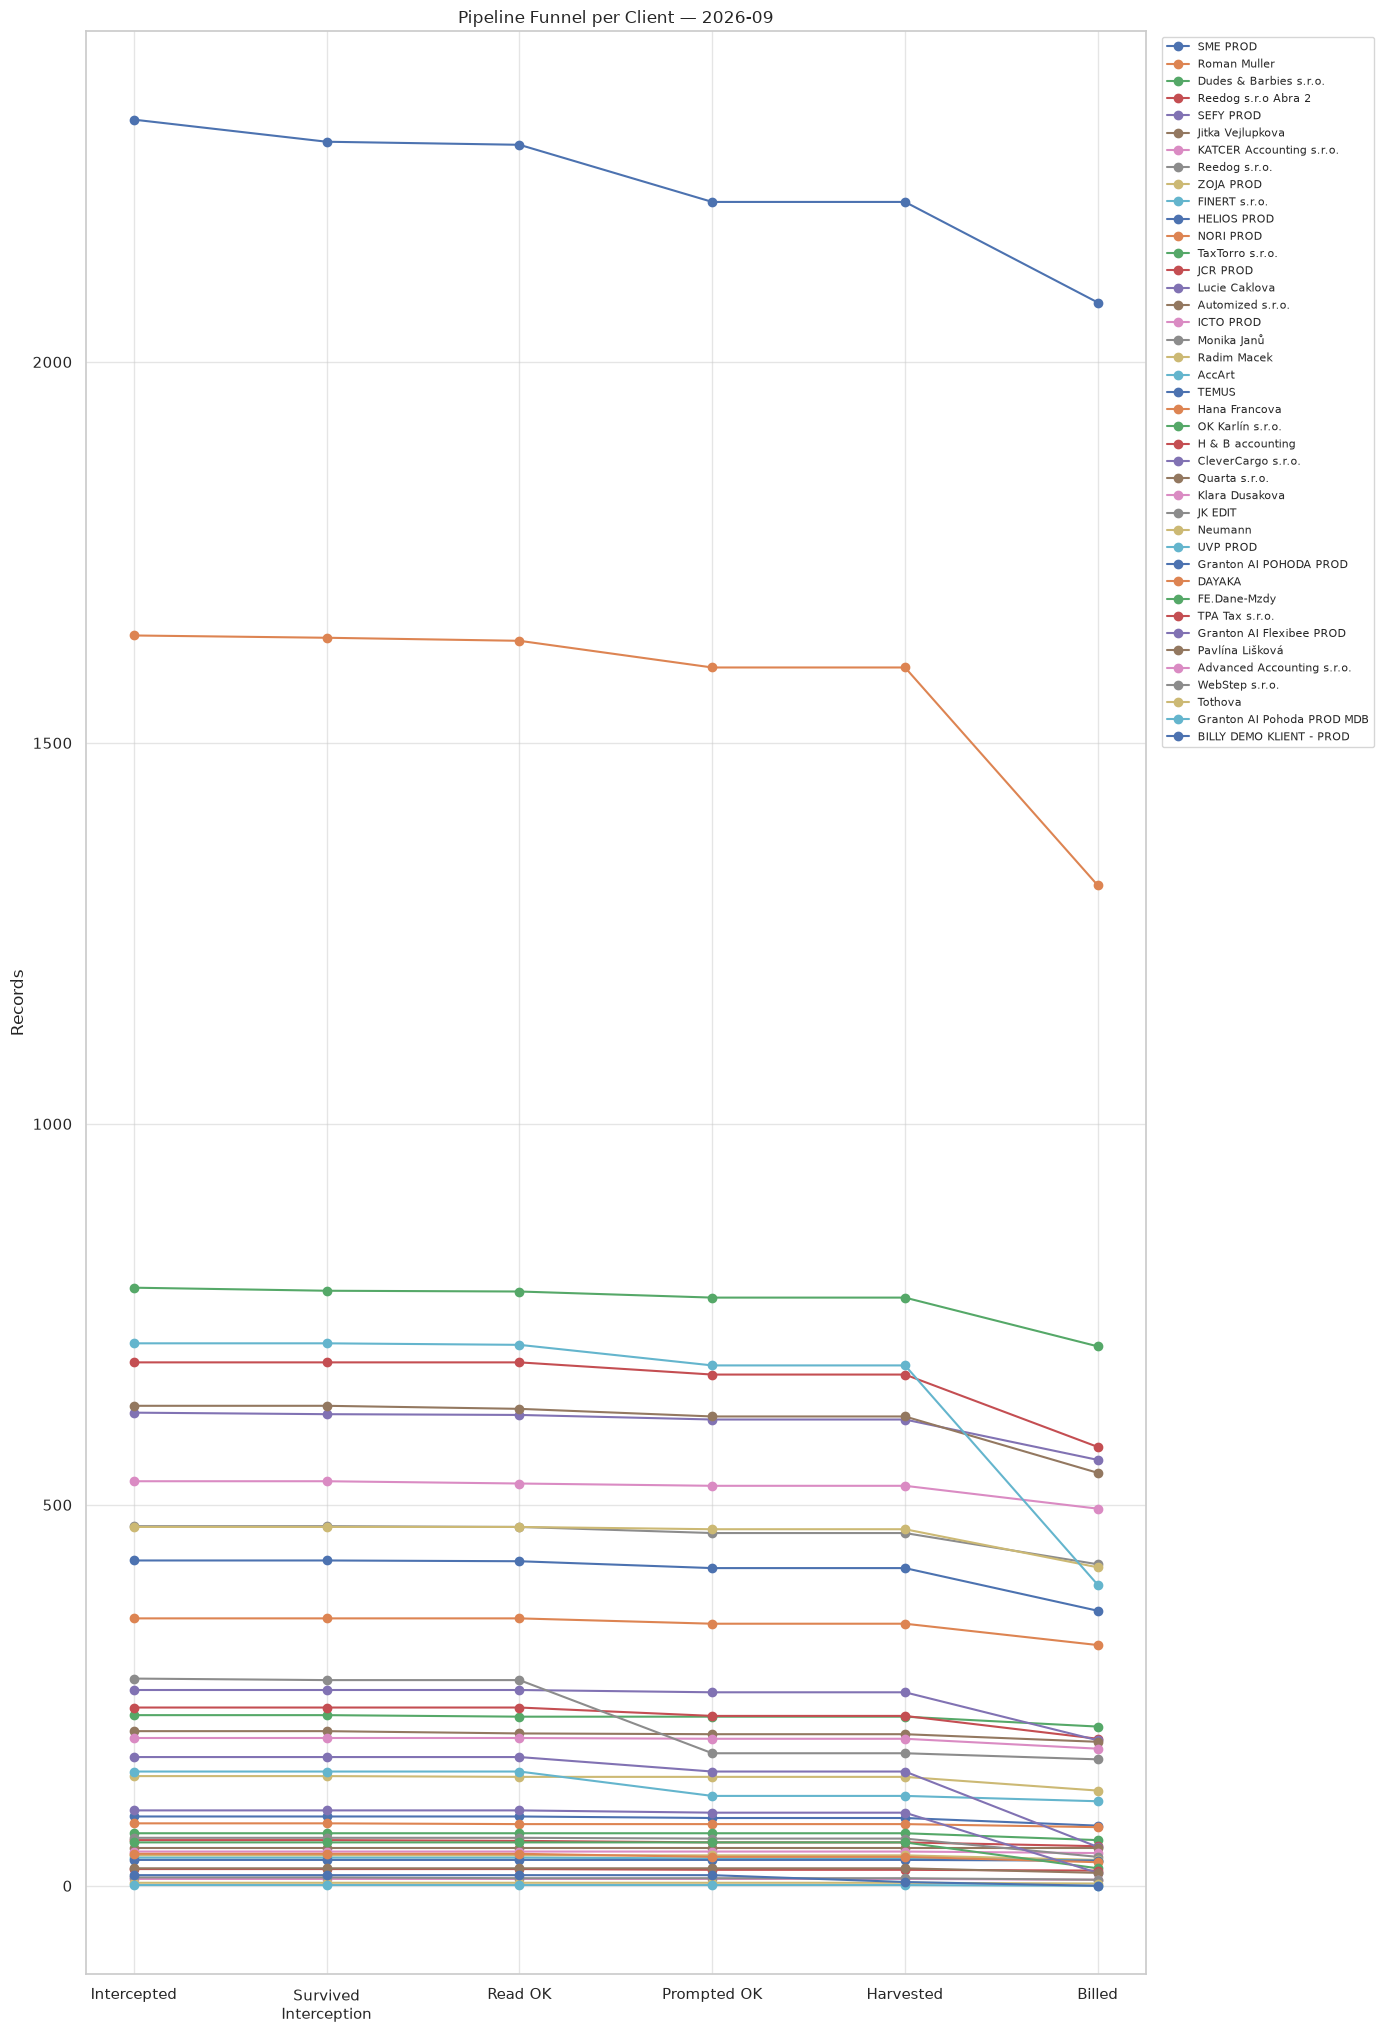

,client_name,total,survived_interception,read_ok,prompted_ok,harvested,billed
0,SME PROD,2318,2289,2285,2210,2210,2078
1,Roman Muller,1641,1638,1634,1599,1599,1313
2,Dudes & Barbies s.r.o.,785,781,780,772,772,708
3,Reedog s.r.o Abra 2,687,687,687,671,671,576
4,SEFY PROD,621,619,618,612,612,559
5,Jitka Vejlupkova,630,630,626,616,616,542
6,KATCER Accounting s.r.o.,531,531,528,525,525,495
7,Reedog s.r.o.,472,472,471,463,463,422
8,ZOJA PROD,471,471,471,468,468,418
9,FINERT s.r.o.,712,712,710,683,683,395


In [17]:
SQL_FUNNEL = """
SELECT
    c.name AS client_name,
    COUNT(*)                                                                        AS total,
    SUM(CASE WHEN r.state_id NOT IN (2,3)             THEN 1 ELSE 0 END)           AS survived_interception,
    SUM(CASE WHEN r.state_id NOT IN (2,3,5)           THEN 1 ELSE 0 END)           AS read_ok,
    SUM(CASE WHEN r.state_id NOT IN (2,3,5,9,10)      THEN 1 ELSE 0 END)           AS prompted_ok,
    SUM(CASE WHEN r.state_id >= 11                     THEN 1 ELSE 0 END)           AS harvested,
    SUM(CASE WHEN r.state_id IN (12,18,20)             THEN 1 ELSE 0 END)           AS billed
FROM record r
INNER JOIN client c ON r.client_id = c.client_id
WHERE r.is_deleted = false
  AND EXTRACT(YEAR  FROM r.created_at) = %(year)s
  AND EXTRACT(MONTH FROM r.created_at) = %(month)s
GROUP BY c.name
ORDER BY billed DESC;
"""

df_funnel = query(SQL_FUNNEL, {'year': REPORT_YEAR, 'month': REPORT_MONTH})
stages = ['total', 'survived_interception', 'read_ok', 'prompted_ok', 'harvested', 'billed']
stage_labels = ['Intercepted', 'Survived\nInterception', 'Read OK', 'Prompted OK', 'Harvested', 'Billed']

fig, ax = plt.subplots(figsize=(14, max(5, len(df_funnel) * 0.5)))
x = range(len(stages))
for _, row in df_funnel.iterrows():
    ax.plot(x, [row[s] for s in stages], marker='o', label=row['client_name'])
ax.set_xticks(range(len(stages)))
ax.set_xticklabels(stage_labels)
ax.set_title(f'Pipeline Funnel per Client — {REPORT_YEAR}-{REPORT_MONTH:02d}')
ax.set_ylabel('Records')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout(); plt.show()
df_funnel

## 13. Error Analysis

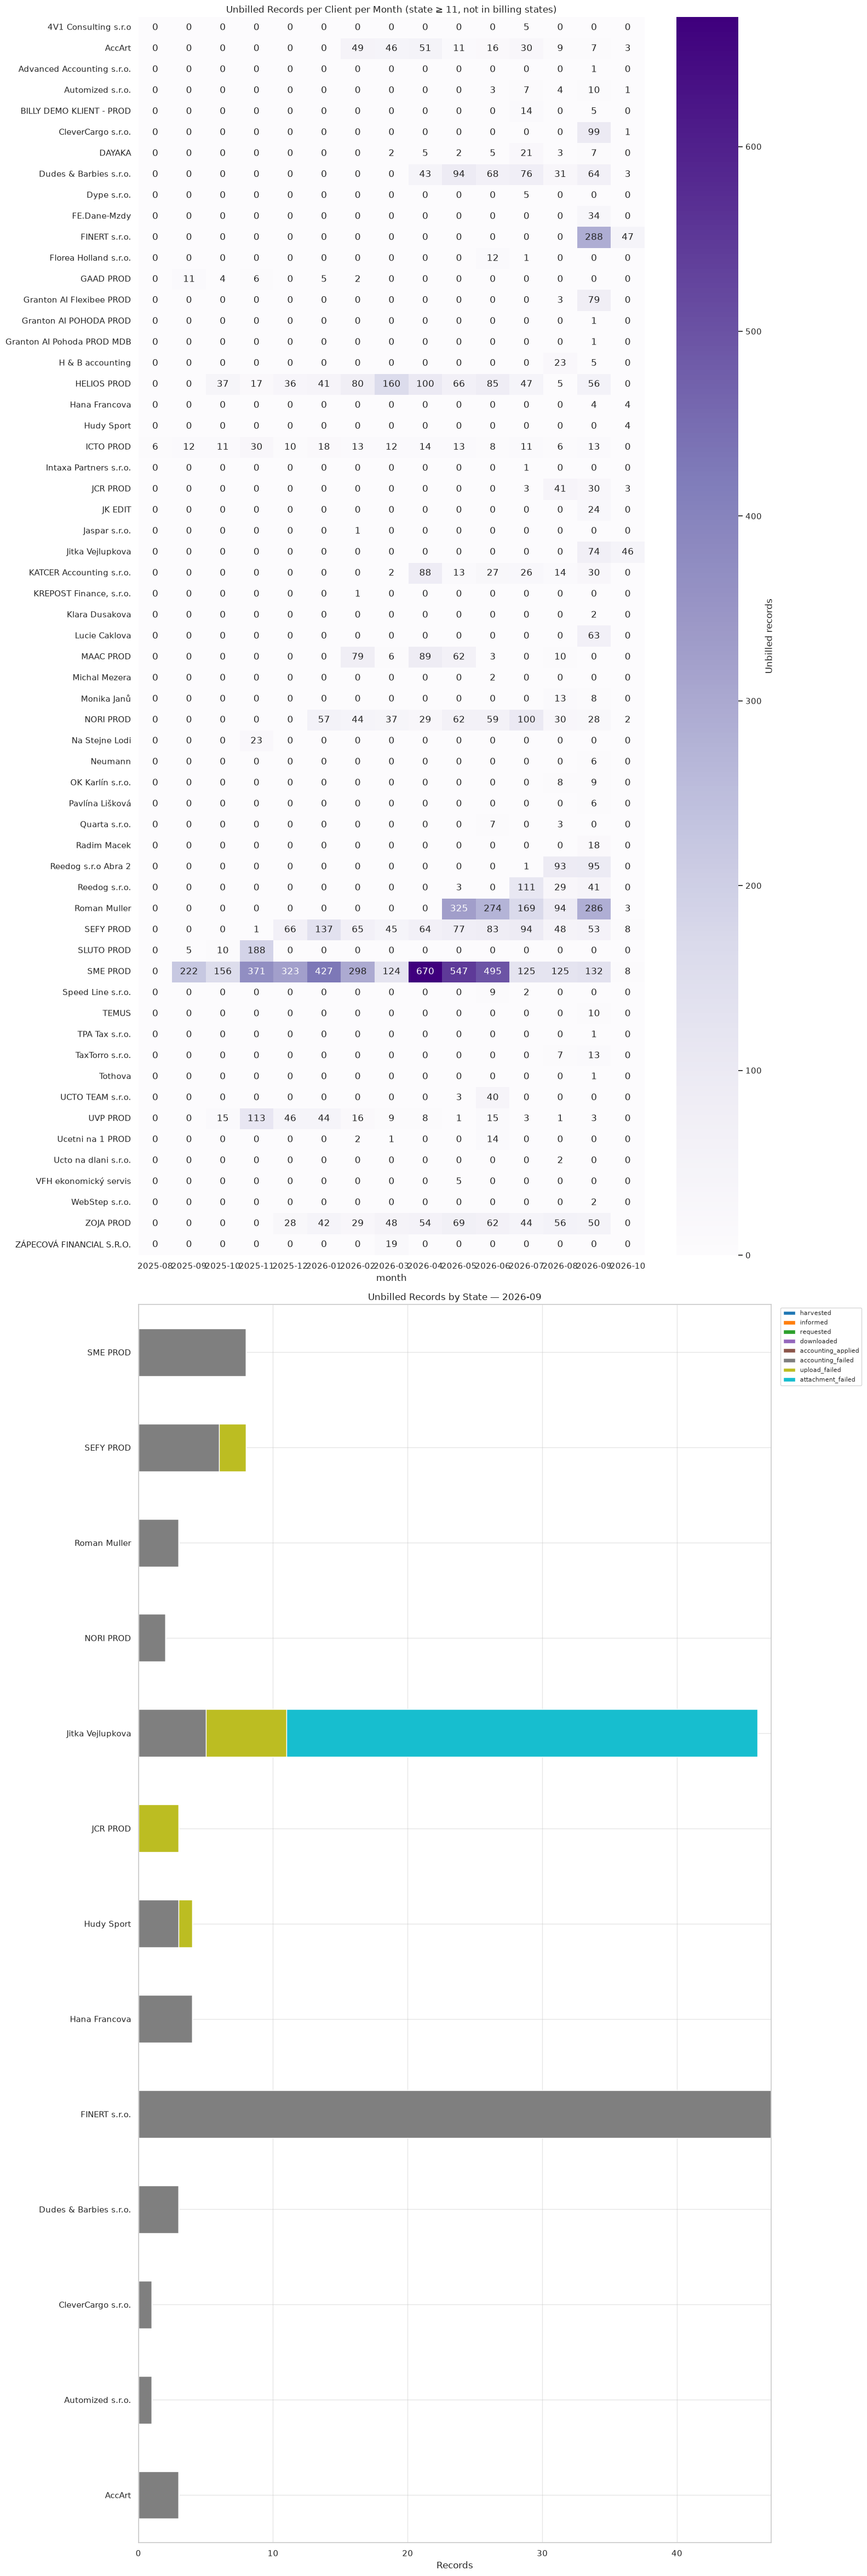

Total unbilled records this month: 133


,client_name,month,unbilled_records,harvested,informed,requested,downloaded,accounting_applied,accounting_failed,upload_failed,attachment_failed
0,4V1 Consulting s.r.o,2026-07-01,5,0,0,0,0,0,4,1,0
1,AccArt,2026-02-01,49,0,0,0,0,0,20,29,0
2,AccArt,2026-03-01,46,0,0,0,0,0,37,9,0
3,AccArt,2026-04-01,51,0,0,0,0,0,37,14,0
4,AccArt,2026-05-01,11,0,0,0,0,0,9,2,0
...,...,...,...,...,...,...,...,...,...,...,...
201,ZOJA PROD,2026-05-01,69,0,0,0,0,0,52,17,0
202,ZOJA PROD,2026-06-01,62,0,0,0,0,0,62,0,0
203,ZOJA PROD,2026-07-01,44,0,0,0,0,0,43,1,0
204,ZOJA PROD,2026-08-01,56,0,0,0,0,0,52,4,0


In [18]:
SQL_UNBILLED = """
SELECT
    c.name AS client_name,
    DATE_TRUNC('month', r.created_at) AS month,
    COUNT(*) AS unbilled_records,
    SUM(CASE WHEN r.state_id = 11 THEN 1 ELSE 0 END) AS harvested,
    SUM(CASE WHEN r.state_id = 13 THEN 1 ELSE 0 END) AS informed,
    SUM(CASE WHEN r.state_id = 14 THEN 1 ELSE 0 END) AS requested,
    SUM(CASE WHEN r.state_id = 15 THEN 1 ELSE 0 END) AS downloaded,
    SUM(CASE WHEN r.state_id = 16 THEN 1 ELSE 0 END) AS accounting_applied,
    SUM(CASE WHEN r.state_id = 17 THEN 1 ELSE 0 END) AS accounting_failed,
    SUM(CASE WHEN r.state_id = 19 THEN 1 ELSE 0 END) AS upload_failed,
    SUM(CASE WHEN r.state_id = 21 THEN 1 ELSE 0 END) AS attachment_failed
FROM record r
INNER JOIN client c ON r.client_id = c.client_id
WHERE r.is_deleted = false
  AND r.state_id IN (11,13,14,15,16,17,19,21)
GROUP BY c.name, DATE_TRUNC('month', r.created_at)
ORDER BY c.name, month;
"""

df_unbilled = query(SQL_UNBILLED)
df_unbilled['month'] = pd.to_datetime(df_unbilled['month'], utc=True).dt.normalize().dt.tz_localize(None) + pd.offsets.MonthBegin(0)

# Monthly unbilled totals per client — heatmap
pivot_unb = df_unbilled.pivot_table(index='client_name', columns='month', values='unbilled_records', fill_value=0)
pivot_unb.columns = pivot_unb.columns.strftime('%Y-%m')

fig, axes = plt.subplots(2, 1, figsize=(16, max(8, len(pivot_unb) * 0.8)))

sns.heatmap(pivot_unb.astype(float), annot=True, fmt='.0f', cmap='Purples',
            ax=axes[0], cbar_kws={'label': 'Unbilled records'})
axes[0].set_title('Unbilled Records per Client per Month (state ≥ 11, not in billing states)')
axes[0].set_ylabel('')

# Current month breakdown by state
unbilled_month = df_unbilled[df_unbilled['month'] == df_unbilled['month'].max()].copy()
if not unbilled_month.empty:
    state_cols = ['harvested', 'informed', 'requested', 'downloaded',
                  'accounting_applied', 'accounting_failed', 'upload_failed', 'attachment_failed']
    unbilled_month.set_index('client_name')[state_cols].plot(kind='barh', stacked=True, ax=axes[1], colormap='tab10')
    axes[1].set_title(f'Unbilled Records by State — {REPORT_YEAR}-{REPORT_MONTH:02d}')
    axes[1].set_xlabel('Records'); axes[1].set_ylabel('')
    axes[1].legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout(); plt.show()

total_unbilled = df_unbilled[df_unbilled['month'] == df_unbilled['month'].max()]['unbilled_records'].sum()
print(f'Total unbilled records this month: {total_unbilled:,}')
df_unbilled

## 17. Unbilled Records (state ≥ 11, not billed)

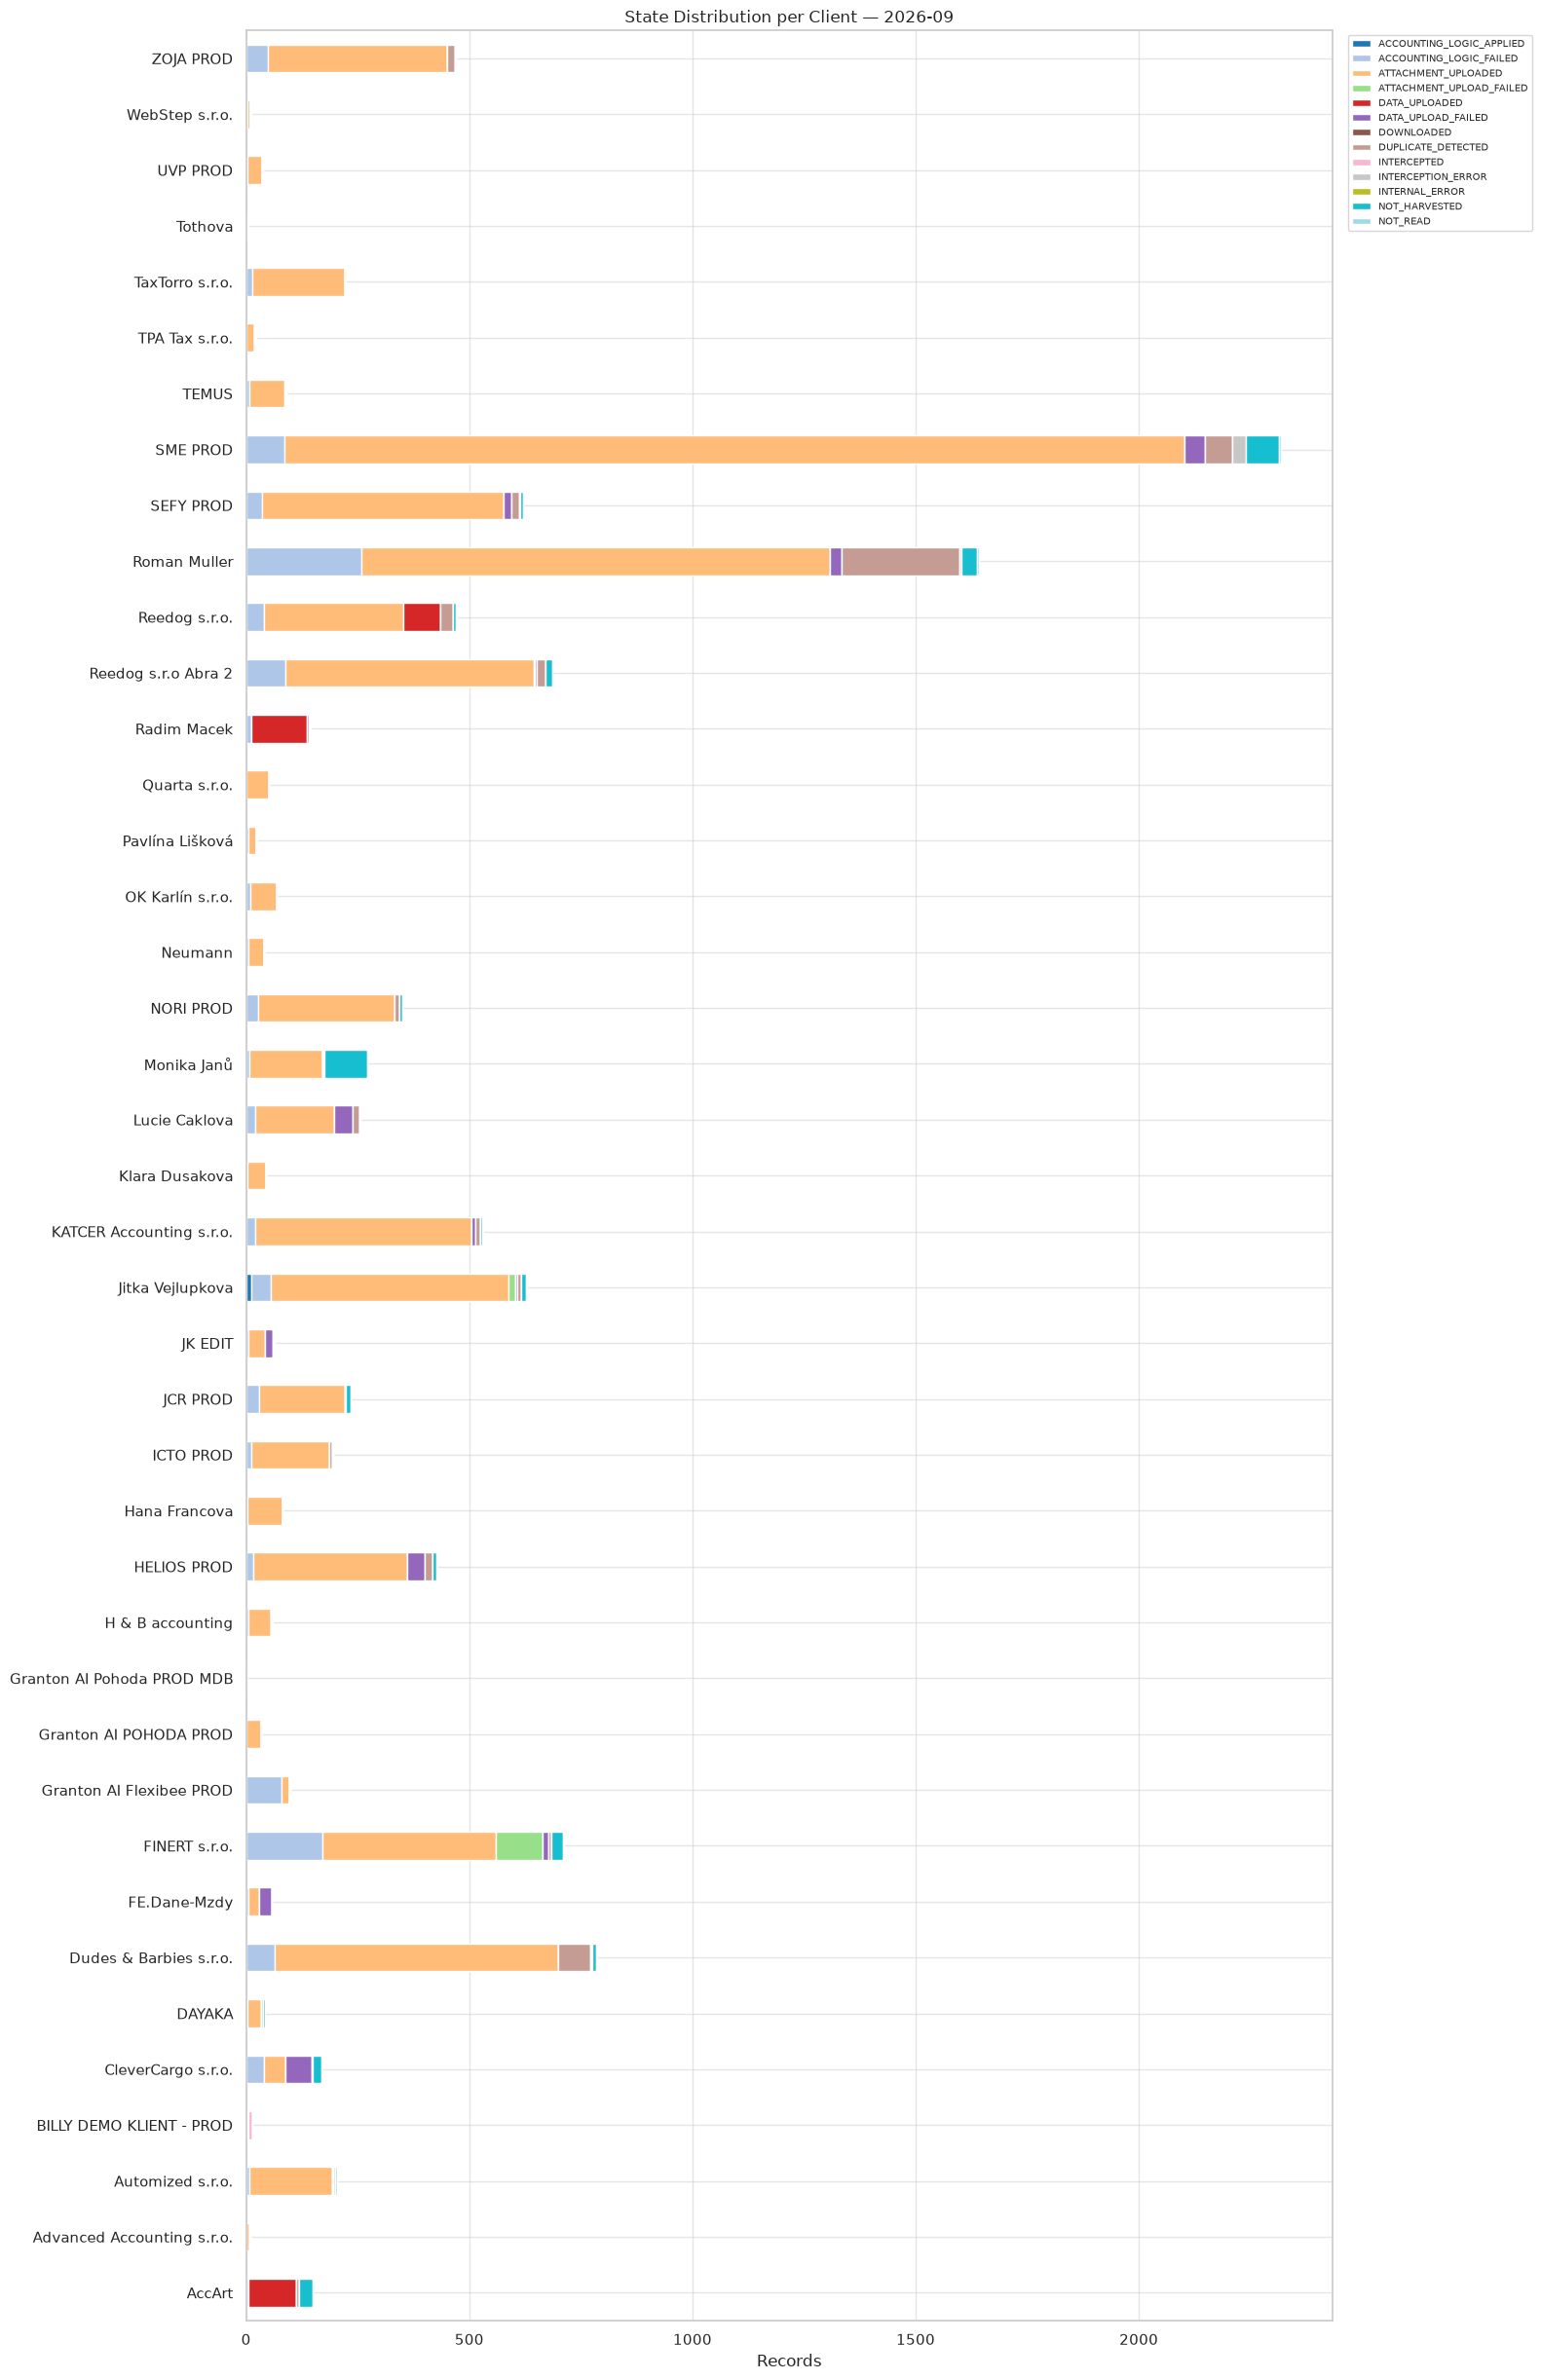

In [19]:
STATE_NAMES = {
    1: 'INTERCEPTED', 2: 'INTERCEPTION_ERROR', 3: 'INTERNAL_ERROR',
    4: 'READ', 5: 'NOT_READ', 6: 'UNRECOGNIZED', 7: 'TRANSFORMED',
    8: 'PROMPTED', 9: 'NOT_PROMPTED', 10: 'NOT_HARVESTED',
    11: 'HARVESTED', 12: 'DUPLICATE_DETECTED', 13: 'INFORMED',
    14: 'REQUESTED', 15: 'DOWNLOADED', 16: 'ACCOUNTING_LOGIC_APPLIED',
    17: 'ACCOUNTING_LOGIC_FAILED', 18: 'DATA_UPLOADED',
    19: 'DATA_UPLOAD_FAILED', 20: 'ATTACHMENT_UPLOADED', 21: 'ATTACHMENT_UPLOAD_FAILED',
}

SQL_STATE_DIST = """
SELECT
    c.name     AS client_name,
    r.state_id,
    COUNT(*)   AS records
FROM record r
INNER JOIN client c ON r.client_id = c.client_id
WHERE r.is_deleted = false
  AND EXTRACT(YEAR  FROM r.created_at) = %(year)s
  AND EXTRACT(MONTH FROM r.created_at) = %(month)s
GROUP BY c.name, r.state_id
ORDER BY c.name, r.state_id;
"""

df_states = query(SQL_STATE_DIST, {'year': REPORT_YEAR, 'month': REPORT_MONTH})
df_states['state_name'] = df_states['state_id'].map(STATE_NAMES)

pivot_states = df_states.pivot_table(index='client_name', columns='state_name', values='records', fill_value=0)

fig, ax = plt.subplots(figsize=(16, max(5, len(pivot_states) * 0.6)))
pivot_states.plot(kind='barh', stacked=True, ax=ax, colormap='tab20')
ax.set_title(f'State Distribution per Client — {REPORT_YEAR}-{REPORT_MONTH:02d}')
ax.set_xlabel('Records'); ax.set_ylabel('')
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout(); plt.show()

## 16. State Distribution

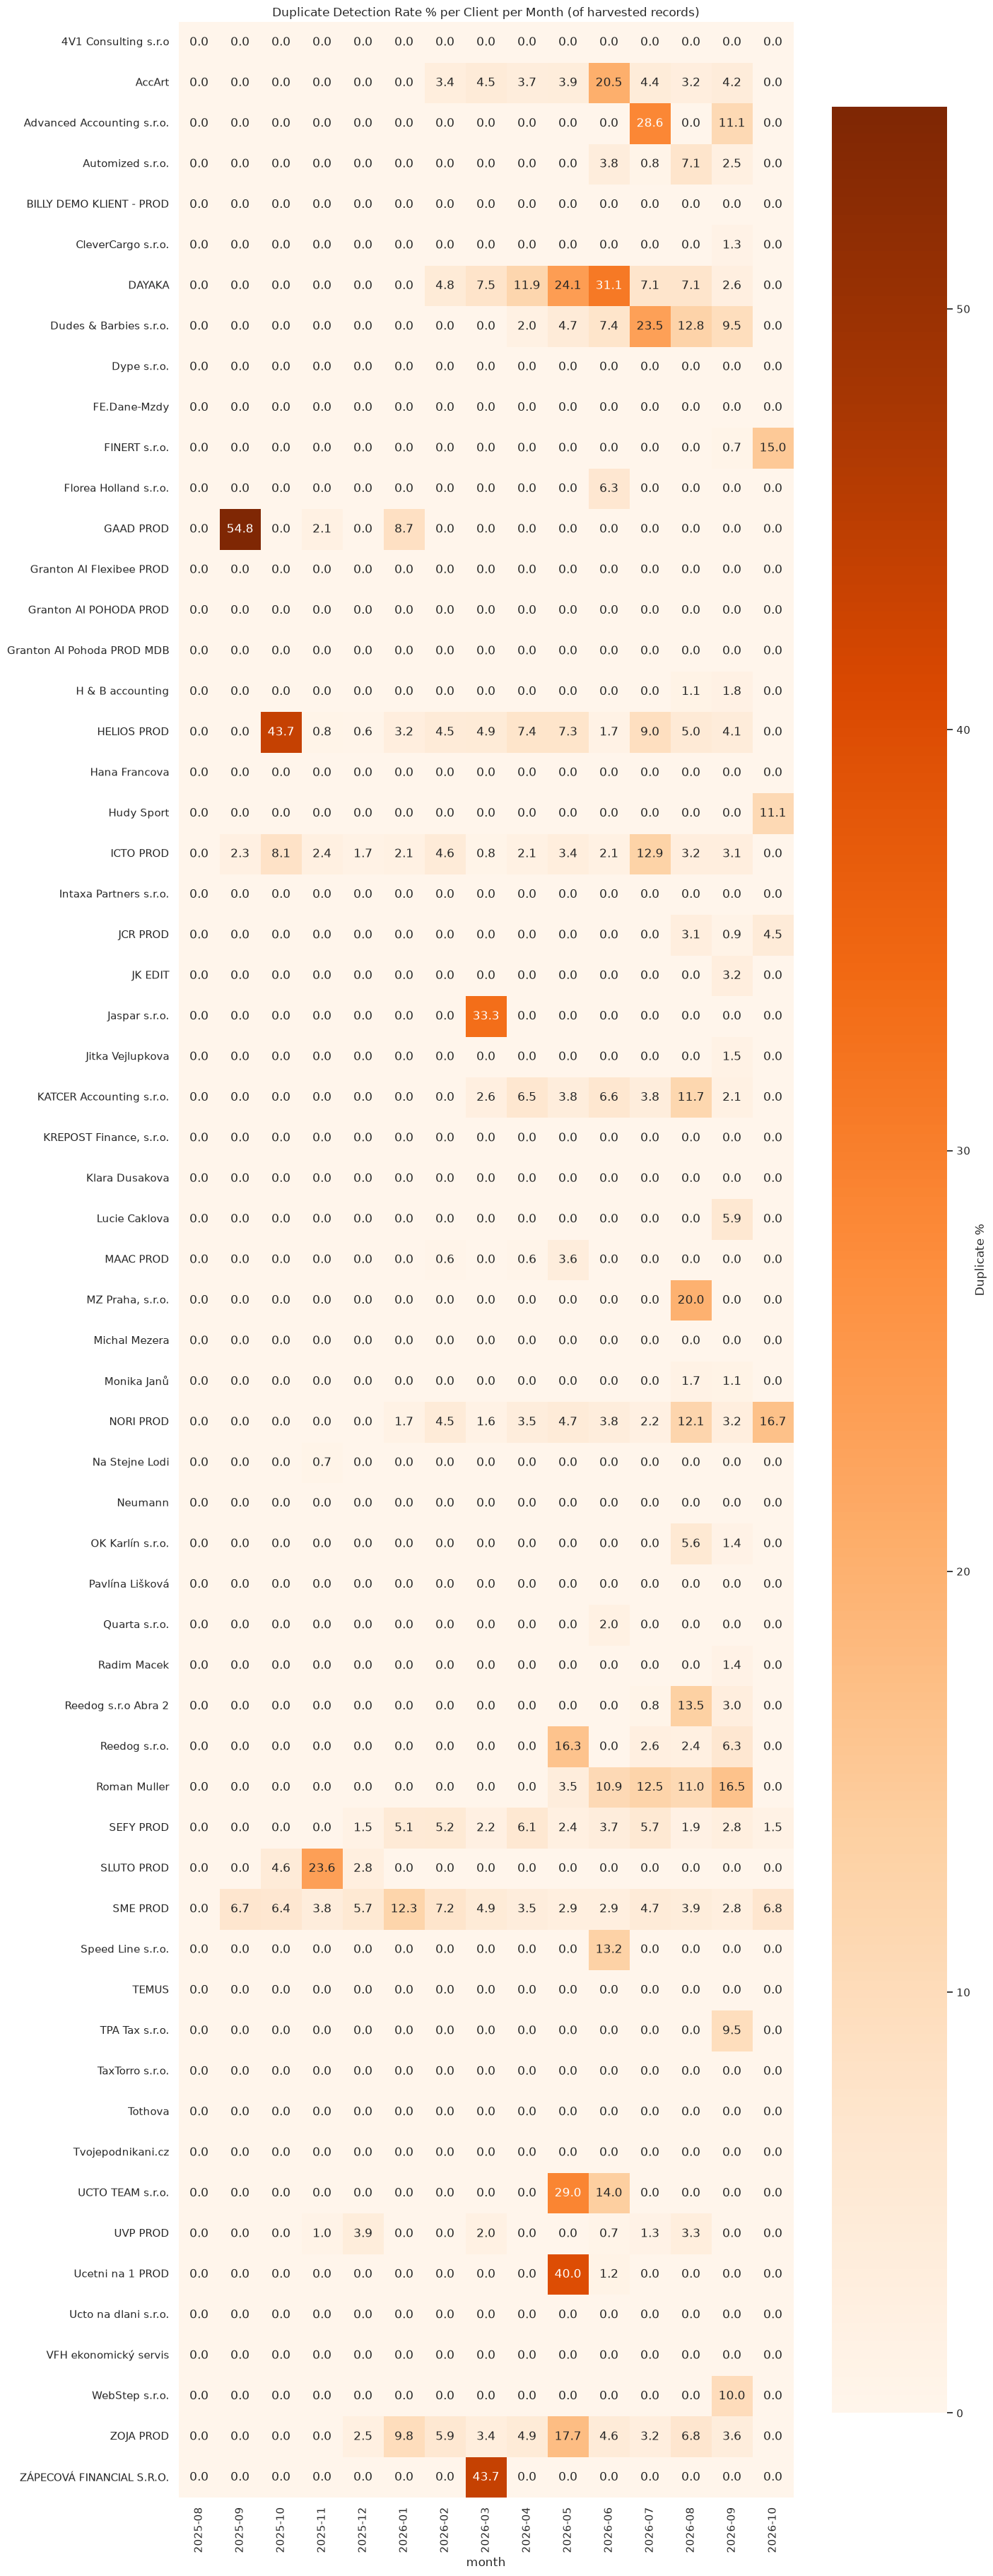

In [20]:
SQL_DUPLICATES = """
SELECT
    c.name AS client_name,
    DATE_TRUNC('month', r.created_at) AS month,
    SUM(CASE WHEN r.state_id = 12  THEN 1 ELSE 0 END) AS duplicates,
    SUM(CASE WHEN r.state_id >= 11 THEN 1 ELSE 0 END) AS total_harvested,
    ROUND(SUM(CASE WHEN r.state_id = 12 THEN 1 ELSE 0 END) * 100.0
        / NULLIF(SUM(CASE WHEN r.state_id >= 11 THEN 1 ELSE 0 END), 0), 1) AS duplicate_pct
FROM record r
INNER JOIN client c ON r.client_id = c.client_id
WHERE r.is_deleted = false
GROUP BY c.name, DATE_TRUNC('month', r.created_at)
ORDER BY c.name, month;
"""

df_dup = query(SQL_DUPLICATES)
df_dup['month']         = pd.to_datetime(df_dup['month'], utc=True).dt.normalize().dt.tz_localize(None) + pd.offsets.MonthBegin(0)
df_dup['duplicate_pct'] = pd.to_numeric(df_dup['duplicate_pct'], errors='coerce')

pivot_dup = df_dup.pivot_table(index='client_name', columns='month', values='duplicate_pct', fill_value=0)
pivot_dup.columns = pivot_dup.columns.strftime('%Y-%m')

fig, ax = plt.subplots(figsize=(14, max(4, len(pivot_dup) * 0.6)))
sns.heatmap(pivot_dup.astype(float), annot=True, fmt='.1f', cmap='Oranges',
            ax=ax, cbar_kws={'label': 'Duplicate %'})
ax.set_title('Duplicate Detection Rate % per Client per Month (of harvested records)')
ax.set_ylabel('')
plt.tight_layout(); plt.show()

## 15. Duplicate Detection Rate

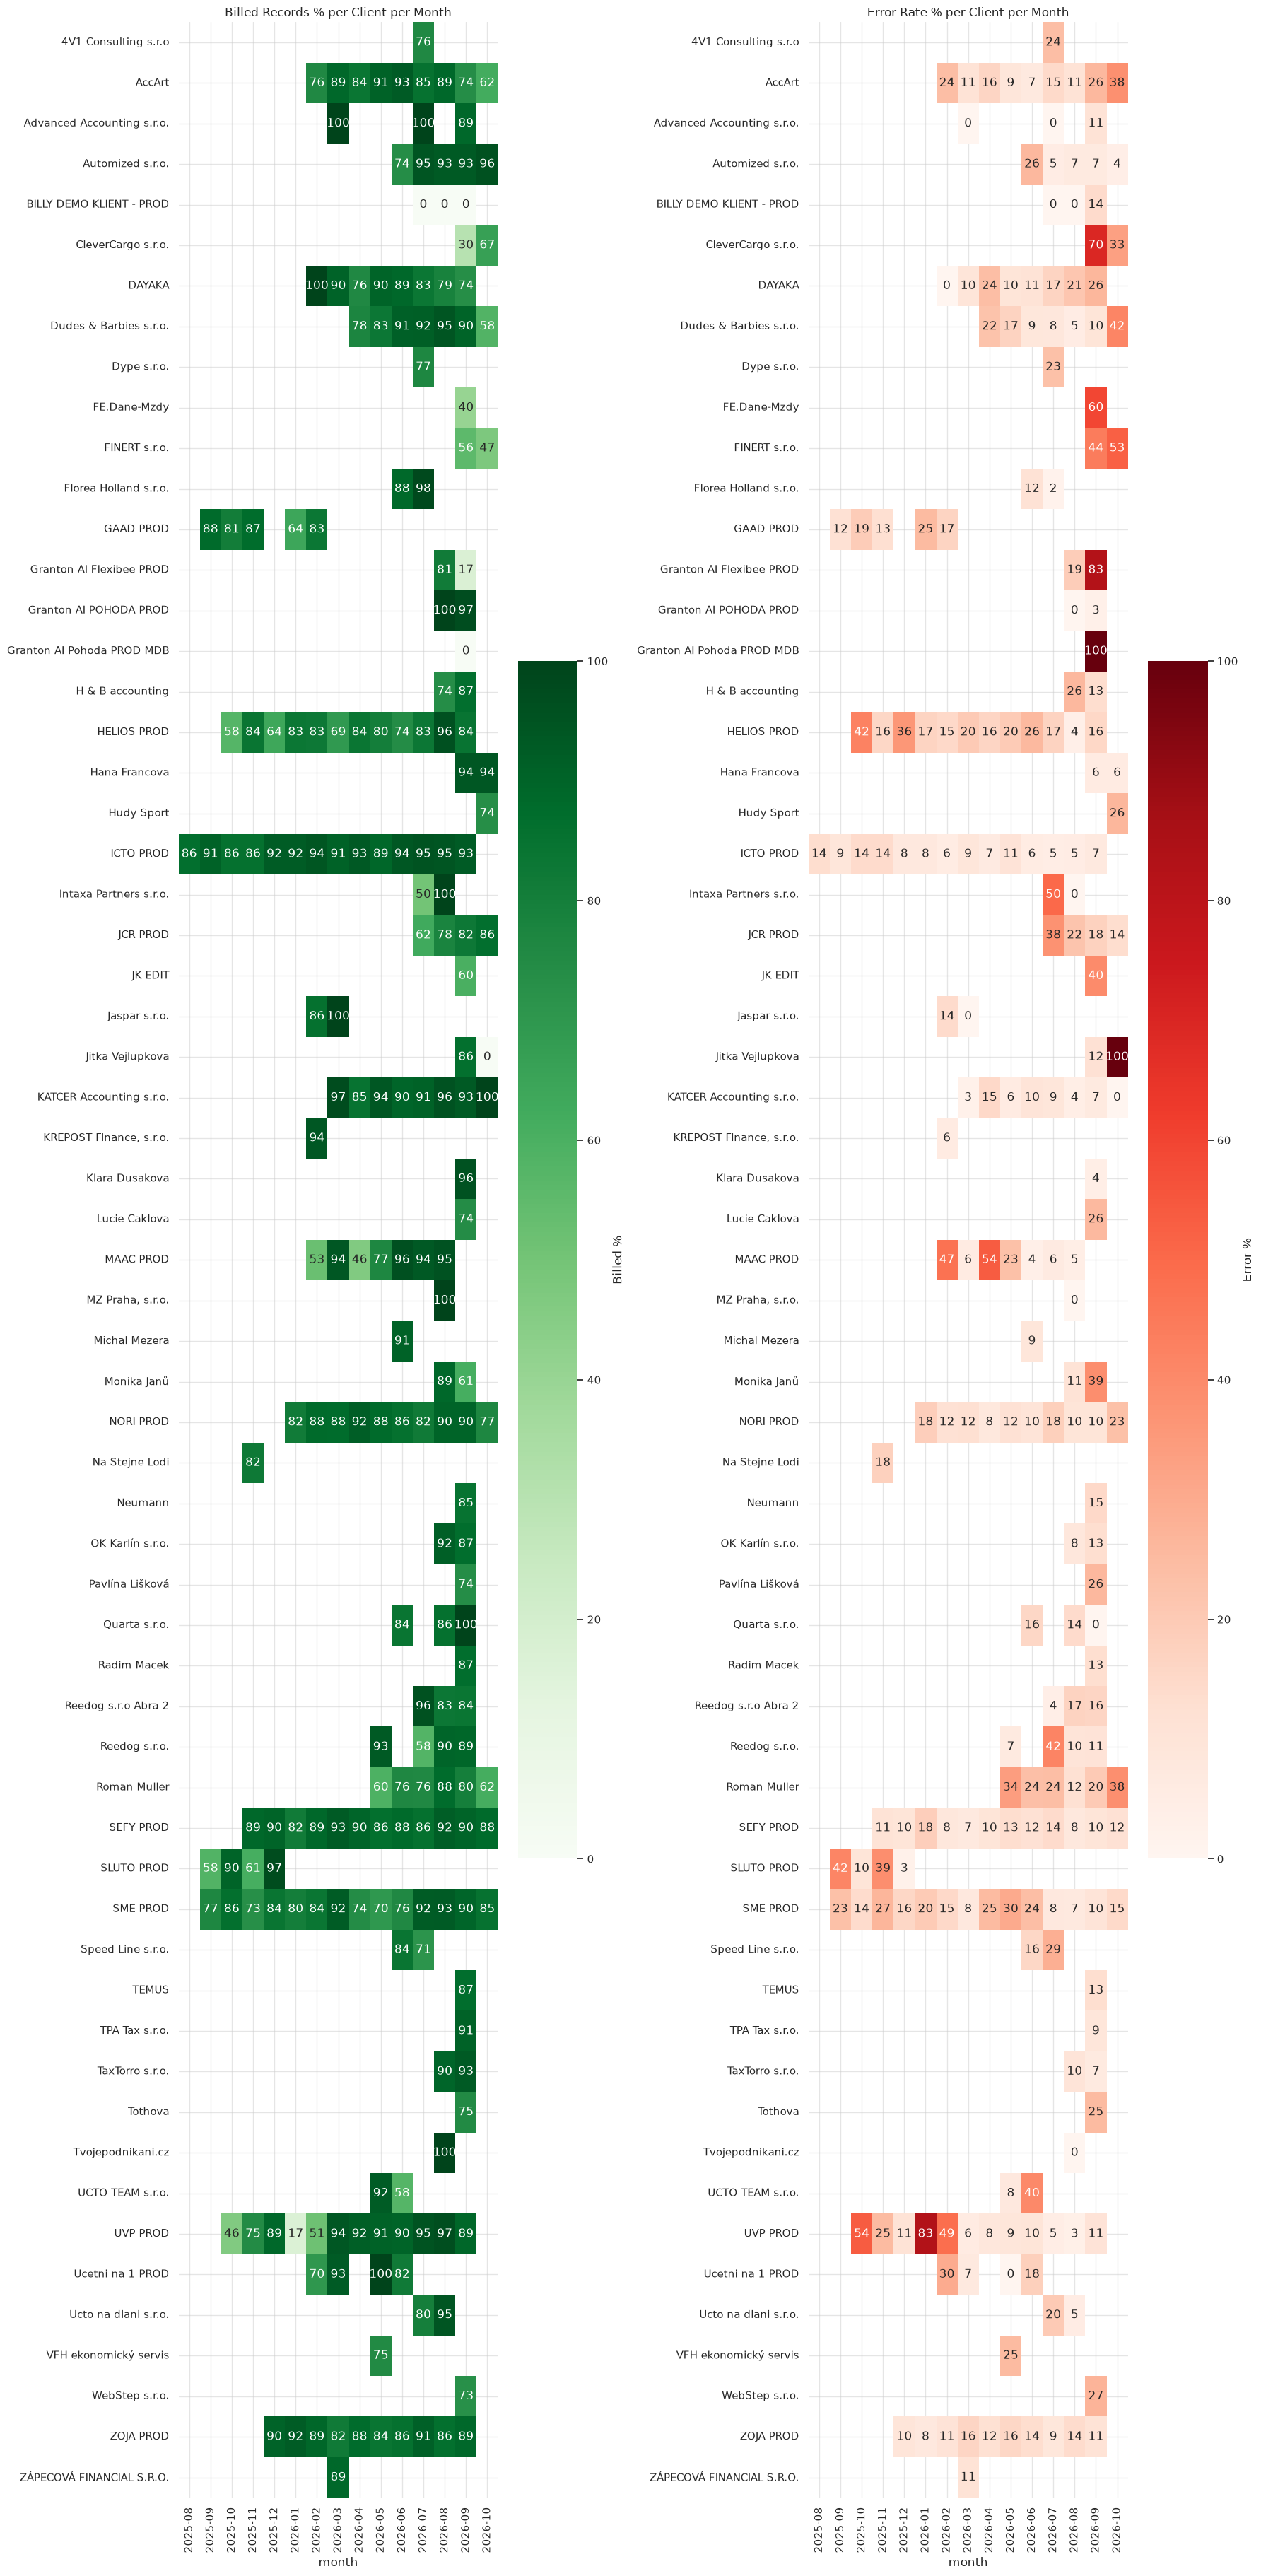

In [21]:
SQL_SUCCESS_TREND = """
SELECT
    c.name AS client_name,
    DATE_TRUNC('month', r.created_at) AS month,
    COUNT(*) AS total,
    SUM(CASE WHEN r.state_id IN (12,18,20)           THEN 1 ELSE 0 END) AS billed,
    SUM(CASE WHEN r.state_id IN (2,3,5,9,10,17,19,21) THEN 1 ELSE 0 END) AS errors,
    ROUND(SUM(CASE WHEN r.state_id IN (12,18,20)            THEN 1 ELSE 0 END) * 100.0 / NULLIF(COUNT(*),0), 1) AS billed_pct,
    ROUND(SUM(CASE WHEN r.state_id IN (2,3,5,9,10,17,19,21) THEN 1 ELSE 0 END) * 100.0 / NULLIF(COUNT(*),0), 1) AS error_pct
FROM record r
INNER JOIN client c ON r.client_id = c.client_id
WHERE r.is_deleted = false
GROUP BY c.name, DATE_TRUNC('month', r.created_at)
ORDER BY c.name, month;
"""

df_suc = query(SQL_SUCCESS_TREND)
df_suc['month']      = pd.to_datetime(df_suc['month'], utc=True).dt.normalize().dt.tz_localize(None) + pd.offsets.MonthBegin(0)
df_suc['billed_pct'] = pd.to_numeric(df_suc['billed_pct'], errors='coerce')
df_suc['error_pct']  = pd.to_numeric(df_suc['error_pct'],  errors='coerce')

pivot_billed = df_suc.pivot(index='client_name', columns='month', values='billed_pct')
pivot_error  = df_suc.pivot(index='client_name', columns='month', values='error_pct')
pivot_billed.columns = pivot_billed.columns.strftime('%Y-%m')
pivot_error.columns  = pivot_error.columns.strftime('%Y-%m')

fig, axes = plt.subplots(1, 2, figsize=(18, max(4, len(pivot_billed) * 0.6)))
sns.heatmap(pivot_billed.astype(float), annot=True, fmt='.0f', cmap='Greens',
            ax=axes[0], cbar_kws={'label': 'Billed %'}, vmin=0, vmax=100)
axes[0].set_title('Billed Records % per Client per Month'); axes[0].set_ylabel('')
sns.heatmap(pivot_error.astype(float), annot=True, fmt='.0f', cmap='Reds',
            ax=axes[1], cbar_kws={'label': 'Error %'}, vmin=0, vmax=100)
axes[1].set_title('Error Rate % per Client per Month'); axes[1].set_ylabel('')
plt.tight_layout(); plt.show()

## 14. Success vs Error Rate Trend

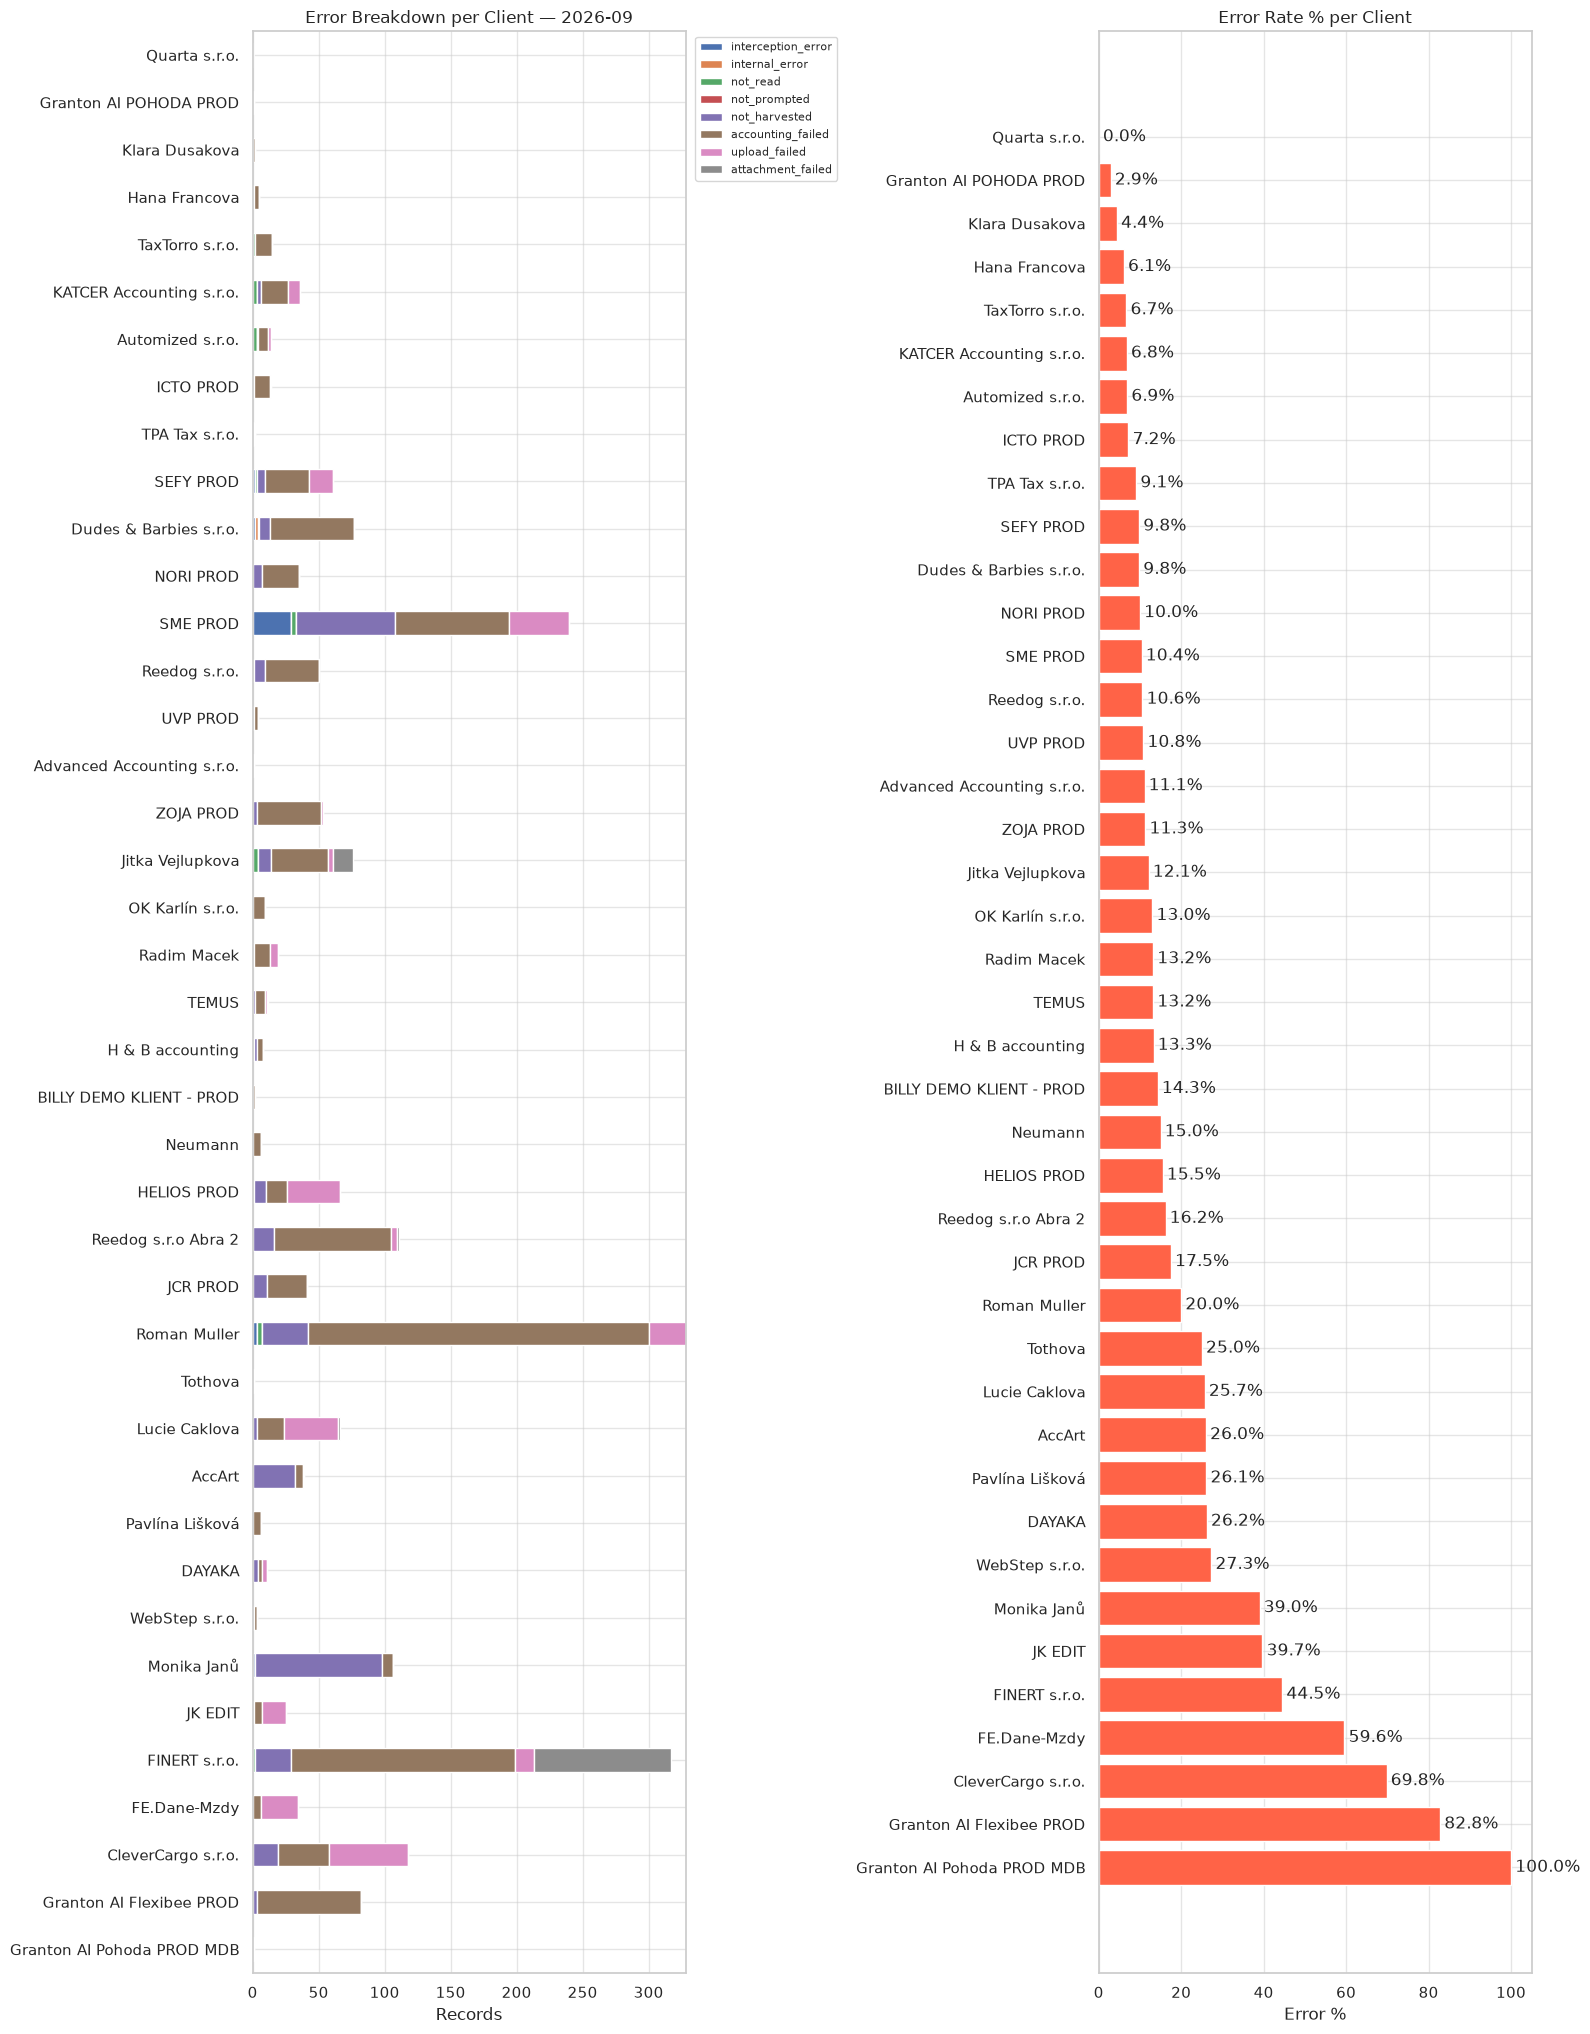

,client_name,total_records,interception_error,internal_error,not_read,not_prompted,not_harvested,accounting_failed,upload_failed,attachment_failed,total_errors,error_pct
0,Granton AI Pohoda PROD MDB,1,0,0,0,0,0,1,0,0,1,100.0
1,Granton AI Flexibee PROD,99,0,0,0,0,3,79,0,0,82,82.8
2,CleverCargo s.r.o.,169,0,0,0,0,19,39,60,0,118,69.8
3,FE.Dane-Mzdy,57,0,0,0,0,0,6,28,0,34,59.6
4,FINERT s.r.o.,712,0,0,2,0,27,170,14,104,317,44.5
5,JK EDIT,63,0,0,0,0,1,6,18,0,25,39.7
6,Monika Janů,272,2,0,0,0,96,8,0,0,106,39.0
7,WebStep s.r.o.,11,0,0,1,0,0,2,0,0,3,27.3
8,DAYAKA,42,0,0,0,0,4,3,4,0,11,26.2
9,Pavlína Lišková,23,0,0,0,0,0,6,0,0,6,26.1


In [22]:
SQL_ERRORS = """
SELECT
    c.name AS client_name,
    COUNT(*) AS total_records,
    SUM(CASE WHEN r.state_id = 2  THEN 1 ELSE 0 END) AS interception_error,
    SUM(CASE WHEN r.state_id = 3  THEN 1 ELSE 0 END) AS internal_error,
    SUM(CASE WHEN r.state_id = 5  THEN 1 ELSE 0 END) AS not_read,
    SUM(CASE WHEN r.state_id = 9  THEN 1 ELSE 0 END) AS not_prompted,
    SUM(CASE WHEN r.state_id = 10 THEN 1 ELSE 0 END) AS not_harvested,
    SUM(CASE WHEN r.state_id = 17 THEN 1 ELSE 0 END) AS accounting_failed,
    SUM(CASE WHEN r.state_id = 19 THEN 1 ELSE 0 END) AS upload_failed,
    SUM(CASE WHEN r.state_id = 21 THEN 1 ELSE 0 END) AS attachment_failed,
    SUM(CASE WHEN r.state_id IN (2,3,5,9,10,17,19,21) THEN 1 ELSE 0 END) AS total_errors,
    ROUND(SUM(CASE WHEN r.state_id IN (2,3,5,9,10,17,19,21) THEN 1 ELSE 0 END)
        * 100.0 / NULLIF(COUNT(*), 0), 1) AS error_pct
FROM record r
INNER JOIN client c ON r.client_id = c.client_id
WHERE r.is_deleted = false
  AND EXTRACT(YEAR  FROM r.created_at) = %(year)s
  AND EXTRACT(MONTH FROM r.created_at) = %(month)s
GROUP BY c.name
ORDER BY error_pct DESC;
"""

df_errors = query(SQL_ERRORS, {'year': REPORT_YEAR, 'month': REPORT_MONTH})
df_errors['error_pct'] = pd.to_numeric(df_errors['error_pct'], errors='coerce')

error_cols = ['interception_error', 'internal_error', 'not_read', 'not_prompted',
              'not_harvested', 'accounting_failed', 'upload_failed', 'attachment_failed']

fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(df_errors) * 0.5)))
df_errors.set_index('client_name')[error_cols].plot(kind='barh', stacked=True, ax=axes[0])
axes[0].set_title(f'Error Breakdown per Client — {REPORT_YEAR}-{REPORT_MONTH:02d}')
axes[0].set_xlabel('Records'); axes[0].set_ylabel('')
axes[0].legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].barh(df_errors['client_name'], df_errors['error_pct'], color='tomato')
axes[1].set_title('Error Rate % per Client'); axes[1].set_xlabel('Error %')
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%', padding=3)
plt.tight_layout(); plt.show()
df_errors

## 18. Averages per Client per Month

Average **documents (records) per client** and **revenue (CZK) per client** for every month.

* *Active clients* = clients with at least one billed record in that month (`STATE_FILTER`), so a client
  that produced nothing is not diluting the average.
* Support data below the charts: active clients, total records, total revenue, avg records/client,
  avg CZK/client and the implied avg CZK/record (blended price per document).
* The most recent month is only complete once the month has ended — read the last point with that in mind.


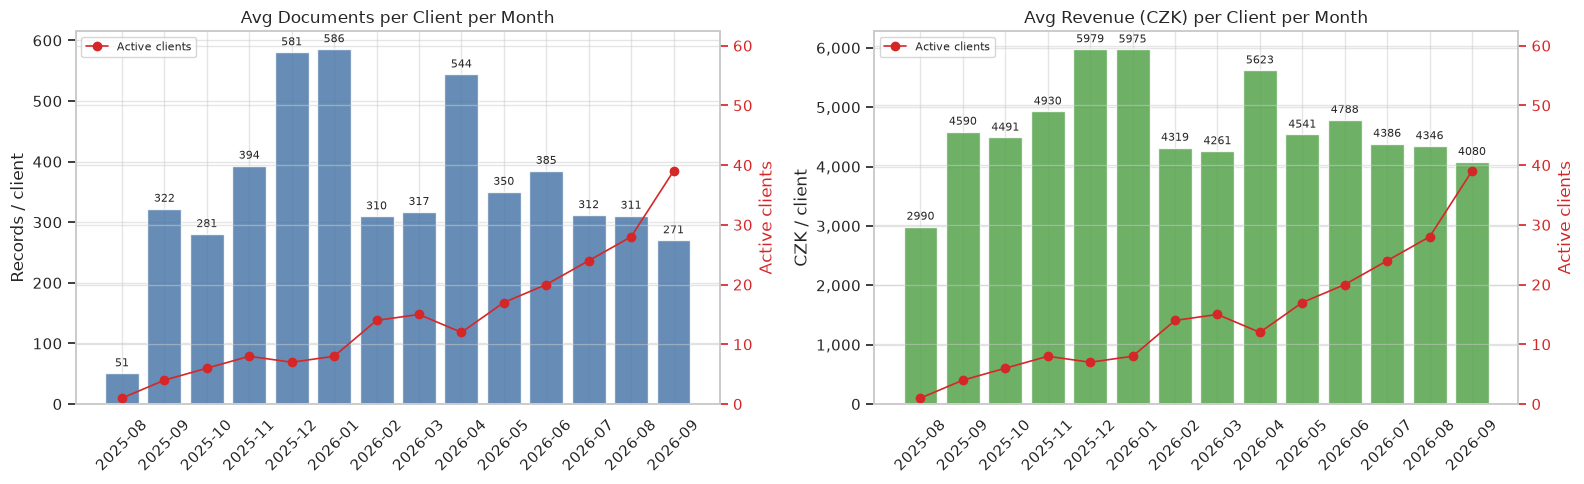

,month,active_clients,total_records,total_revenue_czk,avg_records_per_client,avg_czk_per_client,avg_czk_per_record
0,2025-08,1,51.0,2990.0,51.0,2990.0,58.63
1,2025-09,4,1290.0,18362.0,322.5,4590.0,14.23
2,2025-10,6,1684.0,26946.0,280.7,4491.0,16.00
3,2025-11,8,3148.0,39439.0,393.5,4930.0,12.53
4,2025-12,7,4065.0,41856.0,580.7,5979.0,10.30
5,2026-01,8,4686.0,47803.0,585.8,5975.0,10.20
6,2026-02,14,4340.0,60472.0,310.0,4319.0,13.93
7,2026-03,15,4757.0,63922.0,317.1,4261.0,13.44
8,2026-04,12,6530.0,67474.0,544.2,5623.0,10.33
9,2026-05,17,5956.0,77194.0,350.4,4541.0,12.96


In [23]:
# Built from df_trend (section 4) — one row per client per month, already billing-filtered.
# Only complete months up to the report month — drops the partial current month
_cutoff = pd.Timestamp(REPORT_YEAR, REPORT_MONTH, 1)
avg_src = df_trend[df_trend['month'] <= _cutoff].copy()
avg_src['records_created']   = avg_src['records_created'].astype(float)
avg_src['monthly_price_czk'] = avg_src['monthly_price_czk'].astype(float)

df_avg = (
    avg_src.groupby('month')
           .agg(active_clients    = ('client_name',       'nunique'),
                total_records     = ('records_created',   'sum'),
                total_revenue_czk = ('monthly_price_czk', 'sum'))
           .reset_index()
           .sort_values('month')
)

df_avg['avg_records_per_client'] = df_avg['total_records']     / df_avg['active_clients']
df_avg['avg_czk_per_client']     = df_avg['total_revenue_czk'] / df_avg['active_clients']
df_avg['avg_czk_per_record']     = df_avg['total_revenue_czk'] / df_avg['total_records'].replace(0, pd.NA)
df_avg['month_label']            = df_avg['month'].dt.strftime('%Y-%m')

# Support table for the PDF / for reading here
avg_table = df_avg[['month_label', 'active_clients', 'total_records', 'total_revenue_czk',
                    'avg_records_per_client', 'avg_czk_per_client', 'avg_czk_per_record']].copy()
avg_table.columns = ['month', 'active_clients', 'total_records', 'total_revenue_czk',
                     'avg_records_per_client', 'avg_czk_per_client', 'avg_czk_per_record']
avg_table = avg_table.round({'avg_records_per_client': 1, 'avg_czk_per_client': 0, 'avg_czk_per_record': 2})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars0 = axes[0].bar(df_avg['month_label'], df_avg['avg_records_per_client'], color='#4c78a8', alpha=0.85)
axes[0].bar_label(bars0, fmt='%.0f', padding=3, fontsize=8)
axes[0].set_title('Avg Documents per Client per Month'); axes[0].set_ylabel('Records / client')

bars1 = axes[1].bar(df_avg['month_label'], df_avg['avg_czk_per_client'], color='#54a24b', alpha=0.85)
axes[1].bar_label(bars1, fmt='%.0f', padding=3, fontsize=8)
axes[1].set_title('Avg Revenue (CZK) per Client per Month'); axes[1].set_ylabel('CZK / client')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax2 = ax.twinx()
    ax2.plot(df_avg['month_label'], df_avg['active_clients'], color='tab:red',
             marker='o', linewidth=1.2, label='Active clients')
    ax2.set_ylabel('Active clients', color='tab:red')
    ax2.tick_params(axis='y', colors='tab:red')
    ax2.set_ylim(0, max(df_avg['active_clients']) * 1.6)
    ax2.legend(loc='upper left', fontsize=8)

plt.tight_layout(); plt.show()

avg_table

## 19. Total Billed Records per Month (all clients)

Total documents we actually **billed** per month across the whole client base — the top-line volume number.

* Same billing filter as everywhere else (`STATE_FILTER`), so this is billed volume, not harvested volume.
* Left chart: total records per month with the month-over-month change % on the secondary axis.
* Right chart: the same totals broken down by client, so you can see which client moved the total.
* Support table: totals, MoM change (absolute and %), running cumulative, active clients and the
  matching revenue.
* The most recent month is partial until the month closes.


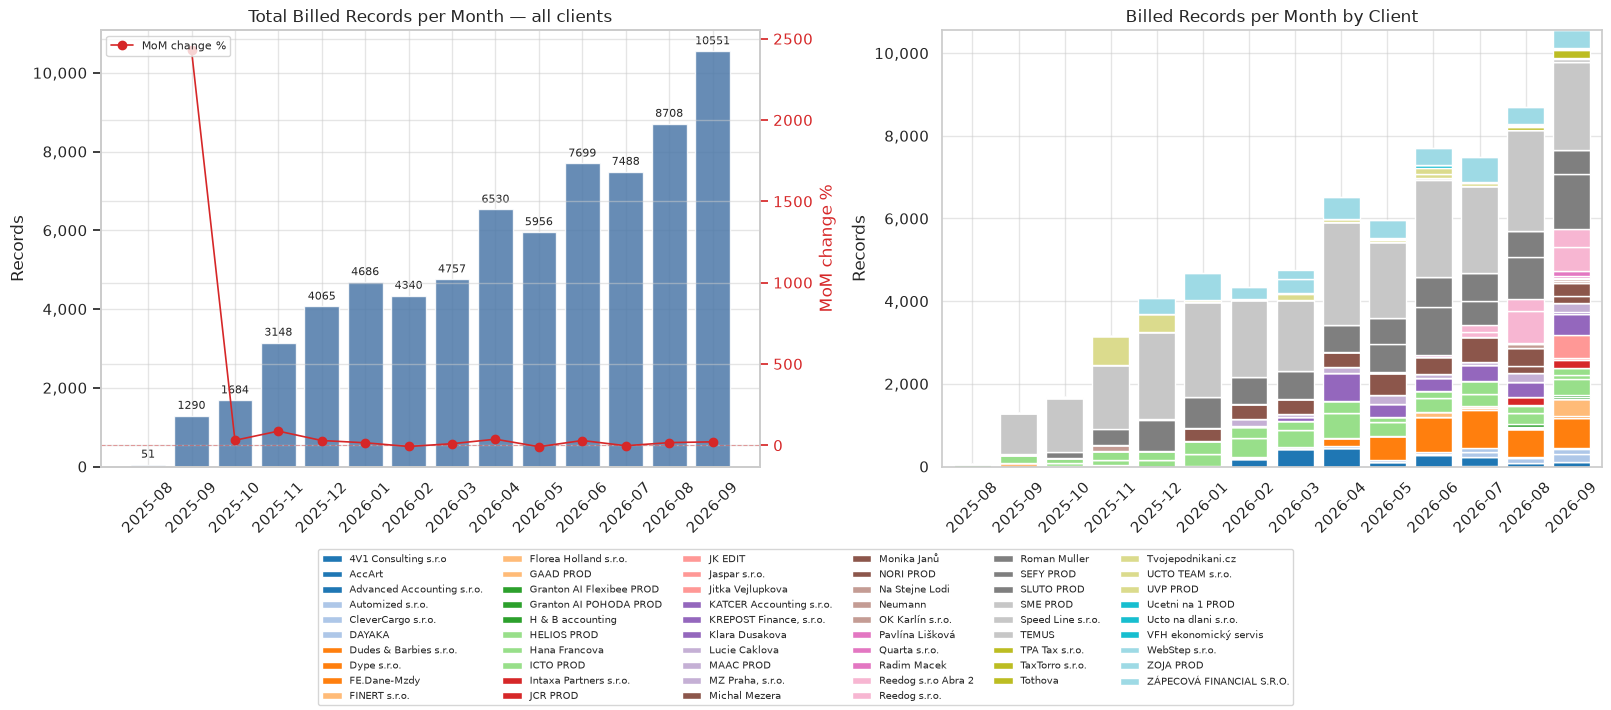

,month,active_clients,total_records,mom_change,mom_pct,cumulative_records,total_revenue_czk
0,2025-08,1,51.0,—,—,51.0,2990.0
1,2025-09,4,1290.0,"+1,239",+2429.4%,1341.0,18362.0
2,2025-10,6,1684.0,+394,+30.5%,3025.0,26946.0
3,2025-11,8,3148.0,"+1,464",+86.9%,6173.0,39439.0
4,2025-12,7,4065.0,+917,+29.1%,10238.0,41856.0
5,2026-01,8,4686.0,+621,+15.3%,14924.0,47803.0
6,2026-02,14,4340.0,-346,-7.4%,19264.0,60472.0
7,2026-03,15,4757.0,+417,+9.6%,24021.0,63922.0
8,2026-04,12,6530.0,"+1,773",+37.3%,30551.0,67474.0
9,2026-05,17,5956.0,-574,-8.8%,36507.0,77194.0


In [24]:
# Built from df_trend (section 4) — billed records per client per month.
# Only complete months up to the report month — drops the partial current month
_cutoff = pd.Timestamp(REPORT_YEAR, REPORT_MONTH, 1)
tot_src = df_trend[df_trend['month'] <= _cutoff].copy()
tot_src['records_created']   = tot_src['records_created'].astype(float)
tot_src['monthly_price_czk'] = tot_src['monthly_price_czk'].astype(float)

df_total = (
    tot_src.groupby('month')
           .agg(active_clients    = ('client_name',       'nunique'),
                total_records     = ('records_created',   'sum'),
                total_revenue_czk = ('monthly_price_czk', 'sum'))
           .reset_index()
           .sort_values('month')
)

df_total['mom_change']         = df_total['total_records'].diff()
df_total['mom_pct']            = df_total['total_records'].pct_change() * 100
df_total['cumulative_records'] = df_total['total_records'].cumsum()
df_total['month_label']        = df_total['month'].dt.strftime('%Y-%m')

# Per-client composition of the monthly total
pivot_total = (tot_src.pivot_table(index='month', columns='client_name',
                                   values='records_created', aggfunc='sum', fill_value=0)
                      .sort_index())
pivot_total.index = pivot_total.index.strftime('%Y-%m')

fig, axes = plt.subplots(1, 2, figsize=(16, 7), layout='constrained')

bars = axes[0].bar(df_total['month_label'], df_total['total_records'], color='#4c78a8', alpha=0.85)
axes[0].bar_label(bars, fmt='%.0f', padding=3, fontsize=8)
axes[0].set_title('Total Billed Records per Month — all clients')
axes[0].set_ylabel('Records')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax_pct = axes[0].twinx()
ax_pct.plot(df_total['month_label'], df_total['mom_pct'], color='tab:red',
            marker='o', linewidth=1.2, label='MoM change %')
ax_pct.axhline(0, color='tab:red', linestyle='--', linewidth=0.8, alpha=0.4)
ax_pct.set_ylabel('MoM change %', color='tab:red')
ax_pct.tick_params(axis='y', colors='tab:red')
ax_pct.legend(loc='upper left', fontsize=8)

pivot_total.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20', width=0.8, legend=False)
axes[1].set_title('Billed Records per Month by Client')
axes[1].set_ylabel('Records'); axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
# One client legend below both charts — too many clients for a side legend
fig.legend(*axes[1].get_legend_handles_labels(), loc='outside lower center', ncol=6, fontsize=7)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.show()

# Support table (MoM columns kept as strings so the first month renders as an em dash)
total_table = pd.DataFrame({
    'month':              df_total['month_label'],
    'active_clients':     df_total['active_clients'],
    'total_records':      df_total['total_records'].round(0),
    'mom_change':         df_total['mom_change'].map(lambda v: '—' if pd.isna(v) else f'{v:+,.0f}'),
    'mom_pct':            df_total['mom_pct'].map(lambda v: '—' if pd.isna(v) else f'{v:+.1f}%'),
    'cumulative_records': df_total['cumulative_records'].round(0),
    'total_revenue_czk':  df_total['total_revenue_czk'].round(0),
}).reset_index(drop=True)

total_table

In [25]:
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime

PDF_PATH = f'client_statistics_{REPORT_YEAR}_{REPORT_MONTH:02d}.pdf'

def _fig(*args, **kwargs):
    return plt.subplots(*args, **{**{'figsize': (14, 6)}, **kwargs})

def _fmt(val):
    """Format a cell value: numbers get thousands separator, strings stay as-is."""
    try:
        n = float(val)
        if n == int(n):
            return f'{int(n):,}'
        return f'{n:,.2f}'
    except (TypeError, ValueError):
        return str(val) if val is not None else ''

with PdfPages(PDF_PATH) as pdf:

    # ── Cover page ─────────────────────────────────────────────
    fig, ax = _fig()
    ax.axis('off')
    ax.text(0.5, 0.65, 'Client Statistics Report',
            ha='center', va='center', fontsize=28, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.50, f'Period: {REPORT_YEAR}-{REPORT_MONTH:02d}',
            ha='center', va='center', fontsize=18, transform=ax.transAxes)
    ax.text(0.5, 0.38, f'Generated: {datetime.today().strftime("%Y-%m-%d")}',
            ha='center', va='center', fontsize=13, color='grey', transform=ax.transAxes)
    pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 1. Current month summary table ─────────────────────────
    col_align = ['left', 'right', 'right', 'right']   # per column

    # Format all values
    fmt_rows = [[_fmt(v) for v in row] for row in df_summary.values]

    fig, ax = _fig(figsize=(14, max(3, len(df_summary) * 0.45)))
    ax.axis('off')
    tbl = ax.table(
        cellText=fmt_rows,
        colLabels=df_summary.columns,
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.5)

    n_rows = len(fmt_rows)
    n_cols = len(df_summary.columns)

    for (row, col), cell in tbl.get_celld().items():
        # Header row
        if row == 0:
            cell.set_facecolor('#2c3e50')
            cell.set_text_props(color='white', fontweight='bold')
            cell.set_edgecolor('white')
            cell.get_text().set_ha(col_align[col] if col < len(col_align) else 'right')
        # ZZ TOTAL row (last data row)
        elif row == n_rows:
            cell.set_facecolor('#ecf0f1')
            cell.set_text_props(fontweight='bold')
            cell.set_edgecolor('#bdc3c7')
            cell.get_text().set_ha(col_align[col] if col < len(col_align) else 'right')
        # Regular rows — alternating background
        else:
            cell.set_facecolor('#ffffff' if row % 2 == 0 else '#f8f9fa')
            cell.set_edgecolor('#dee2e6')
            cell.get_text().set_ha(col_align[col] if col < len(col_align) else 'right')

        # Add right padding for numeric cells
        if col > 0:
            cell.PAD = 0.08

    ax.set_title(f'Current Month Summary — {REPORT_YEAR}-{REPORT_MONTH:02d}',
                 fontsize=14, fontweight='bold', pad=16)
    pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 2. Records & revenue bar charts ────────────────────────
    fig, axes = _fig(1, 2, figsize=(14, 5))
    axes[0].barh(clients.client_name, clients.records_created)
    axes[0].set_title(f'Records Created — {REPORT_YEAR}-{REPORT_MONTH:02d}'); axes[0].set_xlabel('Records')
    axes[1].barh(clients.client_name, clients.monthly_price_czk)
    axes[1].set_title(f'Monthly Price (CZK) — {REPORT_YEAR}-{REPORT_MONTH:02d}'); axes[1].set_xlabel('CZK')
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 3. MoM growth heatmap ──────────────────────────────────
    pivot = df_mom.pivot(index='client_name', columns='month', values='revenue_growth_pct')
    pivot.columns = pivot.columns.strftime('%Y-%m')
    fig, ax = _fig(figsize=(14, max(4, len(pivot) * 0.6)))
    sns.heatmap(pivot.astype(float), annot=True, fmt='.0f', center=0, cmap='RdYlGn',
                linewidths=0.5, ax=ax, cbar_kws={'label': 'Revenue growth %'})
    ax.set_title('Month-over-Month Revenue Growth % per Client'); ax.set_ylabel(''); ax.set_xlabel('')
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 4. Revenue trend lines ─────────────────────────────────
    fig, axes = _fig(1, 2, figsize=(16, 7), layout='constrained')
    for client, grp in df_trend.groupby('client_name'):
        axes[0].plot(grp['month'], grp['records_created'], marker='o', label=client)
        axes[1].plot(grp['month'], grp['monthly_price_czk'], marker='o', label=client)
    axes[0].set_title('Records Created per Month per Client'); axes[0].set_ylabel('Records')
    axes[1].set_title('Revenue (CZK) per Month per Client'); axes[1].set_ylabel('CZK')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    fig.legend(*axes[0].get_legend_handles_labels(), loc='outside lower center', ncol=6, fontsize=7)
    for ax in axes: ax.tick_params(axis='x', rotation=30)
    pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 5. Cumulative YTD revenue ──────────────────────────────
    fig, ax = _fig(figsize=(12, 5))
    ax.bar(df_cum['month'], df_cum['monthly_revenue_czk'], width=20, alpha=0.6, label='Monthly revenue')
    ax2 = ax.twinx()
    ax2.plot(df_cum['month'], df_cum['cumulative_revenue_czk'], color='tab:red', marker='o', label='Cumulative YTD')
    ax.set_title(f'Monthly & Cumulative YTD Revenue {REPORT_YEAR} (CZK)')
    ax.set_ylabel('Monthly (CZK)'); ax2.set_ylabel('Cumulative (CZK)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.tick_params(axis='x', rotation=30)
    l1, lb1 = ax.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
    ax.legend(l1+l2, lb1+lb2, loc='upper left')
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 6. Daily heatmap ───────────────────────────────────────
    pivot_d = df_daily.pivot_table(index='client_name', columns='day', values='records_created', fill_value=0)
    pivot_d.columns = pivot_d.columns.strftime('%d')
    fig, ax = _fig(figsize=(16, max(4, len(pivot_d) * 0.6)))
    sns.heatmap(pivot_d, cmap='YlOrRd', linewidths=0.3, ax=ax, cbar_kws={'label': 'Records'})
    ax.set_title(f'Daily Document Volume per Client — {REPORT_YEAR}-{REPORT_MONTH:02d}')
    ax.set_xlabel('Day'); ax.set_ylabel(''); ax.tick_params(axis='x', rotation=0)
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 7. Harvest efficiency ──────────────────────────────────
    fig, ax = _fig(figsize=(10, max(4, len(df_eff) * 0.5)))
    bars = ax.barh(df_eff['client_name'], df_eff['records_per_job'])
    ax.bar_label(bars, fmt='%.1f', padding=3)
    ax.set_title('Records per Harvest Job (all time)'); ax.set_xlabel('Records / Job')
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 8. Pareto ──────────────────────────────────────────────
    fig, ax = _fig(figsize=(12, 5))
    ax.bar(df_pareto['client_name'], df_pareto['records_created'], alpha=0.7)
    ax2 = ax.twinx()
    ax2.plot(df_pareto['client_name'], df_pareto['cumulative_pct'], color='tab:red', marker='o')
    ax2.axhline(80, color='tab:red', linestyle='--', alpha=0.4, label='80 %')
    ax.set_title('Pareto: Records per Client (all time)'); ax.set_ylabel('Records')
    ax2.set_ylabel('Cumulative %'); ax2.set_ylim(0, 105)
    ax.tick_params(axis='x', rotation=30); ax2.legend()
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 9. LLM cost heatmap ────────────────────────────────────
    pivot_llm = df_llm.pivot_table(index='client_name', columns='month', values='total_cost_eur', fill_value=0)
    pivot_llm.columns = pivot_llm.columns.strftime('%Y-%m')
    fig, ax = _fig(figsize=(14, max(4, len(pivot_llm) * 0.6)))
    sns.heatmap(pivot_llm, annot=True, fmt='.2f', cmap='Blues', ax=ax, cbar_kws={'label': 'Cost (EUR)'})
    ax.set_title('LLM Cost (EUR) per Client per Month'); ax.set_ylabel('')
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 10. Model usage ────────────────────────────────────────
    fig, axes = _fig(1, 2, figsize=(16, 5))
    pivot_calls = df_models.pivot_table(index='month', columns='model_name', values='llm_calls', fill_value=0)
    pivot_calls.index = pivot_calls.index.strftime('%Y-%m')   # categorical labels -> avoids ts-plot freq error
    pivot_calls.plot(kind='bar', stacked=True, ax=axes[0])
    axes[0].set_title('LLM Calls per Model per Month'); axes[0].set_ylabel('Calls')
    axes[0].tick_params(axis='x', rotation=30); axes[0].legend(fontsize=8)
    pivot_cost = df_models.pivot_table(index='month', columns='model_name', values='total_cost_eur', fill_value=0)
    pivot_cost.index = pivot_cost.index.strftime('%Y-%m')
    pivot_cost.plot(kind='bar', stacked=True, ax=axes[1])
    axes[1].set_title('LLM Cost (EUR) per Model per Month'); axes[1].set_ylabel('EUR')
    axes[1].tick_params(axis='x', rotation=30); axes[1].legend(fontsize=8)
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 11. LLM cost trend ─────────────────────────────────────
    fig, ax = _fig(figsize=(12, 5))
    ax.bar(df_llm_trend['month'], df_llm_trend['cost_eur'], width=20, alpha=0.6, label='Monthly cost')
    ax2 = ax.twinx()
    ax2.plot(df_llm_trend['month'], df_llm_trend['cumulative_cost_eur'], color='tab:red', marker='o', label='Cumulative')
    ax.set_title('Monthly & Cumulative LLM Cost (EUR)')
    ax.set_ylabel('Monthly cost (EUR)'); ax2.set_ylabel('Cumulative (EUR)')
    ax.tick_params(axis='x', rotation=30)
    l1, lb1 = ax.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
    ax.legend(l1+l2, lb1+lb2, loc='upper left')
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 12. Pipeline funnel ────────────────────────────────────
    fig, ax = _fig(figsize=(14, max(5, len(df_funnel) * 0.5)))
    x = range(len(stages))
    for _, row in df_funnel.iterrows():
        ax.plot(x, [row[s] for s in stages], marker='o', label=row['client_name'])
    ax.set_xticks(range(len(stages))); ax.set_xticklabels(stage_labels)
    ax.set_title(f'Pipeline Funnel per Client — {REPORT_YEAR}-{REPORT_MONTH:02d}'); ax.set_ylabel('Records')
    ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 13. Error analysis ─────────────────────────────────────
    fig, axes = _fig(1, 2, figsize=(16, max(5, len(df_errors) * 0.5)))
    df_errors.set_index('client_name')[error_cols].plot(kind='barh', stacked=True, ax=axes[0])
    axes[0].set_title(f'Error Breakdown per Client — {REPORT_YEAR}-{REPORT_MONTH:02d}')
    axes[0].set_xlabel('Records'); axes[0].set_ylabel('')
    axes[0].legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
    axes[1].barh(df_errors['client_name'], df_errors['error_pct'], color='tomato')
    axes[1].set_title('Error Rate % per Client'); axes[1].set_xlabel('Error %')
    axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%', padding=3)
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 14. Success vs error trend ─────────────────────────────
    fig, axes = _fig(1, 2, figsize=(18, max(4, len(pivot_billed) * 0.6)))
    sns.heatmap(pivot_billed.astype(float), annot=True, fmt='.0f', cmap='Greens',
                ax=axes[0], cbar_kws={'label': 'Billed %'}, vmin=0, vmax=100)
    axes[0].set_title('Billed Records % per Client per Month'); axes[0].set_ylabel('')
    sns.heatmap(pivot_error.astype(float), annot=True, fmt='.0f', cmap='Reds',
                ax=axes[1], cbar_kws={'label': 'Error %'}, vmin=0, vmax=100)
    axes[1].set_title('Error Rate % per Client per Month'); axes[1].set_ylabel('')
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 15. Duplicate detection rate ───────────────────────────
    fig, ax = _fig(figsize=(14, max(4, len(pivot_dup) * 0.6)))
    sns.heatmap(pivot_dup.astype(float), annot=True, fmt='.1f', cmap='Oranges',
                ax=ax, cbar_kws={'label': 'Duplicate %'})
    ax.set_title('Duplicate Detection Rate % per Client per Month (of harvested records)')
    ax.set_ylabel('')
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 16. State distribution ─────────────────────────────────
    fig, ax = _fig(figsize=(16, max(5, len(pivot_states) * 0.6)))
    pivot_states.plot(kind='barh', stacked=True, ax=ax, colormap='tab20')
    ax.set_title(f'State Distribution per Client — {REPORT_YEAR}-{REPORT_MONTH:02d}')
    ax.set_xlabel('Records'); ax.set_ylabel('')
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 17. Unbilled records ───────────────────────────────────
    fig, axes = plt.subplots(2, 1, figsize=(16, max(8, len(pivot_unb) * 0.8)))
    sns.heatmap(pivot_unb.astype(float), annot=True, fmt='.0f', cmap='Purples',
                ax=axes[0], cbar_kws={'label': 'Unbilled records'})
    axes[0].set_title('Unbilled Records per Client per Month (state ≥ 11, not billed)'); axes[0].set_ylabel('')
    if not unbilled_month.empty:
        unbilled_month.set_index('client_name')[state_cols].plot(kind='barh', stacked=True, ax=axes[1], colormap='tab10')
        axes[1].set_title(f'Unbilled Records by State — {REPORT_YEAR}-{REPORT_MONTH:02d}')
        axes[1].set_xlabel('Records'); axes[1].set_ylabel('')
        axes[1].legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 18. Averages per client per month ──────────────────────
    fig, axes = _fig(1, 2, figsize=(16, 5))
    b0 = axes[0].bar(df_avg['month_label'], df_avg['avg_records_per_client'], color='#4c78a8', alpha=0.85)
    axes[0].bar_label(b0, fmt='%.0f', padding=3, fontsize=8)
    axes[0].set_title('Avg Documents per Client per Month'); axes[0].set_ylabel('Records / client')
    b1 = axes[1].bar(df_avg['month_label'], df_avg['avg_czk_per_client'], color='#54a24b', alpha=0.85)
    axes[1].bar_label(b1, fmt='%.0f', padding=3, fontsize=8)
    axes[1].set_title('Avg Revenue (CZK) per Client per Month'); axes[1].set_ylabel('CZK / client')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    for ax in axes:
        ax.tick_params(axis='x', rotation=45)
        axr = ax.twinx()
        axr.plot(df_avg['month_label'], df_avg['active_clients'], color='tab:red',
                 marker='o', linewidth=1.2, label='Active clients')
        axr.set_ylabel('Active clients', color='tab:red'); axr.tick_params(axis='y', colors='tab:red')
        axr.set_ylim(0, max(df_avg['active_clients']) * 1.6)
        axr.legend(loc='upper left', fontsize=8)
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 18b. Support data table ────────────────────────────────
    avg_align = ['left'] + ['right'] * (len(avg_table.columns) - 1)
    avg_rows  = [[_fmt(v) for v in row] for row in avg_table.values]
    fig, ax = _fig(figsize=(14, max(3, len(avg_table) * 0.45)))
    ax.axis('off')
    tbl = ax.table(cellText=avg_rows, colLabels=avg_table.columns, loc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.5)
    for (row, col), cell in tbl.get_celld().items():
        cell.get_text().set_ha(avg_align[col])
        if row == 0:
            cell.set_facecolor('#2c3e50')
            cell.set_text_props(color='white', fontweight='bold')
            cell.set_edgecolor('white')
        else:
            cell.set_facecolor('#ffffff' if row % 2 == 0 else '#f8f9fa')
            cell.set_edgecolor('#dee2e6')
        if col > 0:
            cell.PAD = 0.08
    ax.set_title('Support Data — Averages per Client per Month',
                 fontsize=14, fontweight='bold', pad=16)
    pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 19. Total billed records per month ─────────────────────
    fig, axes = _fig(1, 2, figsize=(16, 7), layout='constrained')
    tb = axes[0].bar(df_total['month_label'], df_total['total_records'], color='#4c78a8', alpha=0.85)
    axes[0].bar_label(tb, fmt='%.0f', padding=3, fontsize=8)
    axes[0].set_title('Total Billed Records per Month — all clients'); axes[0].set_ylabel('Records')
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    axp = axes[0].twinx()
    axp.plot(df_total['month_label'], df_total['mom_pct'], color='tab:red',
             marker='o', linewidth=1.2, label='MoM change %')
    axp.axhline(0, color='tab:red', linestyle='--', linewidth=0.8, alpha=0.4)
    axp.set_ylabel('MoM change %', color='tab:red'); axp.tick_params(axis='y', colors='tab:red')
    axp.legend(loc='upper left', fontsize=8)
    pivot_total.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20', width=0.8, legend=False)
    axes[1].set_title('Billed Records per Month by Client')
    axes[1].set_ylabel('Records'); axes[1].set_xlabel('')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    fig.legend(*axes[1].get_legend_handles_labels(), loc='outside lower center', ncol=6, fontsize=7)
    for ax in axes: ax.tick_params(axis='x', rotation=45)
    pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 19b. Support data table ────────────────────────────────
    tot_align = ['left'] + ['right'] * (len(total_table.columns) - 1)
    # pre-formatted strings (mom_change / mom_pct) pass through _fmt untouched
    tot_rows  = [[v if isinstance(v, str) else _fmt(v) for v in row] for row in total_table.values]
    fig, ax = _fig(figsize=(14, max(3, len(total_table) * 0.45)))
    ax.axis('off')
    tbl = ax.table(cellText=tot_rows, colLabels=total_table.columns, loc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.5)
    for (row, col), cell in tbl.get_celld().items():
        cell.get_text().set_ha(tot_align[col])
        if row == 0:
            cell.set_facecolor('#2c3e50')
            cell.set_text_props(color='white', fontweight='bold')
            cell.set_edgecolor('white')
        else:
            cell.set_facecolor('#ffffff' if row % 2 == 0 else '#f8f9fa')
            cell.set_edgecolor('#dee2e6')
        if col > 0:
            cell.PAD = 0.08
    ax.set_title('Support Data — Total Billed Records per Month',
                 fontsize=14, fontweight='bold', pad=16)
    pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    pdf.infodict()['Title']   = f'Client Statistics {REPORT_YEAR}-{REPORT_MONTH:02d}'
    pdf.infodict()['Author']  = 'Granton AI'
    pdf.infodict()['Subject'] = 'Board Report'

print(f'Saved → {PDF_PATH} (19 sections)')

Saved → client_statistics_2026_09.pdf (19 sections)


## 20. Per-Client Usage PDF & CSV

Separate PDF with one page per client: records created per month, from the client's first month up to the report month.
The same numbers are exported to a CSV (rows = clients, columns = months).

In [26]:
# ── Per-client usage report: one client per page ──────────────
from matplotlib.backends.backend_pdf import PdfPages

# Built from df_trend (section 4). Months run from each client's first month
# up to the report month; months without records show as 0 so drops stay visible.
CLIENT_PDF_PATH = f'client_usage_per_client_{REPORT_YEAR}_{REPORT_MONTH:02d}.pdf'

_cutoff = pd.Timestamp(REPORT_YEAR, REPORT_MONTH, 1)
usage = df_trend[df_trend['month'] <= _cutoff].copy()
usage['records_created'] = usage['records_created'].astype(float)
all_months = pd.date_range(usage['month'].min(), _cutoff, freq='MS')

with PdfPages(CLIENT_PDF_PATH) as pdf:
    for client, grp in sorted(usage.groupby('client_name'), key=lambda kv: kv[0].lower()):
        series = (grp.groupby('month')['records_created'].sum()
                     .reindex(all_months[all_months >= grp['month'].min()], fill_value=0))
        avg = series.mean()

        fig, ax = plt.subplots(figsize=(14, 6), layout='constrained')
        ax.plot(series.index, series.values, marker='o', linewidth=2, color='#4c78a8', label='Records created')
        for x, y in series.items():
            ax.annotate(f'{y:,.0f}', (x, y), textcoords='offset points', xytext=(0, 8),
                        ha='center', fontsize=8)
        ax.axhline(avg, color='tab:grey', linestyle='--', linewidth=1, label=f'Average: {avg:,.0f} / month')

        ax.set_xlim(all_months[0] - pd.Timedelta(days=15), all_months[-1] + pd.Timedelta(days=15))
        ax.set_ylim(0, max(series.max(), 1) * 1.15)
        ax.set_xticks(all_months)
        ax.set_xticklabels(all_months.strftime('%Y-%m'), rotation=45)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
        ax.set_ylabel('Records')
        fig.suptitle(f'{client} — Records Created per Month', fontsize=14, fontweight='bold')
        ax.set_title(f'Total: {series.sum():,.0f} records  ·  '
                     f'Last month ({_cutoff:%Y-%m}): {series.iloc[-1]:,.0f}',
                     fontsize=9, color='grey')
        ax.legend(loc='upper left', fontsize=8)

        pdf.savefig(fig); plt.close(fig)

    pdf.infodict()['Title']   = f'Client Usage per Client {REPORT_YEAR}-{REPORT_MONTH:02d}'
    pdf.infodict()['Author']  = 'Granton AI'
    pdf.infodict()['Subject'] = 'Records created per month, one client per page'

print(f'Saved → {CLIENT_PDF_PATH} ({usage["client_name"].nunique()} clients)')

Saved → client_usage_per_client_2026_09.pdf (58 clients)


In [27]:
# ── Per-client usage table: clients × months → CSV ────────────
# Same numbers as the per-client PDF: records created per month, up to the report month.
# Empty cell = client had not started yet; 0 = active client with no records that month.
CLIENT_CSV_PATH = f'client_usage_per_client_{REPORT_YEAR}_{REPORT_MONTH:02d}.csv'

_cutoff = pd.Timestamp(REPORT_YEAR, REPORT_MONTH, 1)
usage = df_trend[df_trend['month'] <= _cutoff]
all_months = pd.date_range(usage['month'].min(), _cutoff, freq='MS')

usage_table = (usage.pivot_table(index='client_name', columns='month', values='records_created', aggfunc='sum')
                    .reindex(columns=all_months))
first_month = usage.groupby('client_name')['month'].min()
for client, start in first_month.items():
    usage_table.loc[client, all_months >= start] = usage_table.loc[client, all_months >= start].fillna(0)

usage_table = usage_table.astype('Int64')
usage_table.columns = all_months.strftime('%Y-%m')
usage_table['Total'] = usage_table.sum(axis=1)
usage_table = usage_table.sort_index(key=lambda idx: idx.str.lower())
usage_table.index.name = 'client'
usage_table.loc['TOTAL'] = usage_table.sum()

# utf-8-sig so Excel shows Czech client names correctly
usage_table.to_csv(CLIENT_CSV_PATH, encoding='utf-8-sig')
print(f'Saved → {CLIENT_CSV_PATH} ({len(usage_table) - 1} clients × {len(all_months)} months)')
usage_table

Saved → client_usage_per_client_2026_09.csv (58 clients × 14 months)


,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09,Total
client,,,,,,,,,,,,,,,
4V1 Consulting s.r.o,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,20,0,0,20
AccArt,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,186,431,449,120,282,200,89,112,1869
Advanced Accounting s.r.o.,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,0,0,0,7,0,8,16
Automized s.r.o.,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,23,122,123,191,459
CleverCargo s.r.o.,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,111,111
DAYAKA,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,21,38,54,28,40,105,11,35,332
Dudes & Barbies s.r.o.,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,186,586,860,905,690,708,3935
Dype s.r.o.,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,49,0,0,49
FE.Dane-Mzdy,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,51,51


## 12. Export to PDF